# 08 - Time-Sensitive Recommendations

**Project:** E-Commerce User Behavior Analysis & Recommendation System  
**Notebook purpose:** Extend the collaborative filtering recommendations from notebook 06 with temporal awareness. Computes category-level conversion lift factors from session data and uses them to re-rank recommendations based on hour of day, day of week, and seasonal patterns.

---

## Environment Setup

This notebook was run on **Kaggle Notebooks** using outputs from notebook 06, session features from notebook 04, and the user category affinity data.

### To reproduce this notebook

1. Go to the repository on GitHub:  
   [ecommerce-behavior-analysis](https://github.com/halleepham/ecommerce-behavior-analysis)
2. Download `notebooks/08_time_sensitive_recommendations.ipynb`
3. Open a new Kaggle notebook
4. Click **"Add Input"** and attach:
   - **halleepham/collaborative-filtering-outputs** (recommendations, similarity matrix, and LOO test set)
   - **kylenaluan/session-features** (session features)
   - **kylenaluan/user-category-affinity** (user category affinity)
5. Run all cells top to bottom

### Data paths

    /kaggle/input/datasets/halleepham/collaborative-filtering-outputs/recommendations.parquet
    /kaggle/input/datasets/halleepham/collaborative-filtering-outputs/adjusted_similarity_matrix.parquet
    /kaggle/input/datasets/halleepham/collaborative-filtering-outputs/loo_test.parquet
    /kaggle/input/datasets/kylenaluan/session-features/session_features.parquet
    /kaggle/input/datasets/kylenaluan/user-category-affinity/user_category_affinity.parquet

### Python version and key libraries

| Library | Version |
|---|---|
| Python | 3.12.12 |
| pandas | 2.3.3 |
| numpy | 2.0.2 |
| pyplot | 3.10.0 |
| seaborn | 0.13.2 |

---

## Scope

**Time-Sensitive Recommendations:** Explores conversion patterns across hour of day, day of week, and date to motivate a category-level temporal re-ranking layer. Computes category x hour and category x day lift factors with shrinkage smoothing, and a seasonal layer based on daily November conversion patterns. The three lift factors are combined by multiplication and used to re-rank the baseline recommendations from notebook 06. Results are compared against the notebook 06 baseline using Recall@5 and NDCG@5.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# File paths
RECOMMENDATIONS_FILE = '/kaggle/input/datasets/halleepham/collaborative-filtering-outputs/recommendations.parquet'
SIMILARITY_FILE = '/kaggle/input/datasets/halleepham/collaborative-filtering-outputs/adjusted_similarity_matrix.parquet'
SESSION_FILE = '/kaggle/input/datasets/kylenaluan/session-features/session_features.parquet'
AFFINITY_FILE = '/kaggle/input/datasets/kylenaluan/user-category-affinity/user_category_affinity.parquet'
LOO_TEST_FILE = '/kaggle/input/datasets/halleepham/collaborative-filtering-outputs/loo_test.parquet'
OUTPUT_DIR = '/kaggle/working'

# Constants
K = 5   # number of recommendations per user — matches notebook 06
RANDOM_SEED = 42  # for reproducibility
SHRINKAGE_FACTOR = 5000

# Verify files exist
print(f'Recommendations file exists: {os.path.exists(RECOMMENDATIONS_FILE)}')
print(f'Similarity matrix file exists: {os.path.exists(SIMILARITY_FILE)}')
print(f'Session features file exists: {os.path.exists(SESSION_FILE)}')
print(f'User category affinity file exists: {os.path.exists(AFFINITY_FILE)}')
print(f'LOO test file exists: {os.path.exists(LOO_TEST_FILE)}')

# Library versions
print(f'\nPython: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'pyplot: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')

Recommendations file exists: True
Similarity matrix file exists: True
Session features file exists: True
User category affinity file exists: True
LOO test file exists: True

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas: 2.3.3
numpy: 2.0.2
pyplot: 3.10.0
seaborn: 0.13.2


---

## 1. Exploratory Data Analysis

* Before building the temporal model, I explore the session dataset to understand conversion patterns across time.
* This informs the lift factor computation and several decisions made later in the notebook.

### 1.1 Session Data Structure
* Load the session features dataset
* Inspect its shape, column types, and first few rows

In [3]:
session_df = pd.read_parquet(SESSION_FILE)

print(f'Shape: {session_df.shape}\n')

print('--- Column dtypes ---')
print(session_df.dtypes)

Shape: (23016650, 16)

--- Column dtypes ---
user_session                     object
user_id                           int32
n_events                          int64
unique_products                   int64
session_start       datetime64[ns, UTC]
session_end         datetime64[ns, UTC]
n_carts                           int64
n_purchases                       int64
n_views                           int64
session_revenue                 float32
duration_seconds                float64
converted                          bool
cart_abandoned                     bool
hour_of_day                       int32
day_of_week                      object
month                             int32
dtype: object


In [4]:
print('\n--- First 5 rows ---')
print(session_df.head())


--- First 5 rows ---
                           user_session    user_id  n_events  unique_products  \
0  00000042-3e3f-42f9-810d-f3d264139c50  515483062         2                1   
1  00000056-a206-40dd-b174-a072550fa38c  513782162         8                7   
2  0000007c-adbf-4ed7-af17-d1fef9763d67  560165420         1                1   
3  00000083-8816-4d58-a9b8-f52f54186edc  546521725        18               14   
4  0000009d-1f5b-40b9-bd23-db4f3d973ae3  457789173         1                1   

              session_start               session_end  n_carts  n_purchases  \
0 2019-10-18 10:54:45+00:00 2019-10-18 10:55:20+00:00        0            0   
1 2019-10-31 06:23:12+00:00 2019-10-31 06:31:25+00:00        0            0   
2 2019-11-18 09:16:19+00:00 2019-11-18 09:16:19+00:00        0            0   
3 2019-10-06 11:24:45+00:00 2019-10-06 11:34:30+00:00        1            1   
4 2019-11-13 06:02:54+00:00 2019-11-13 06:02:54+00:00        0            0   

   n_views  sess

#### 1.1 Observations
* The dataset has 23,016,650 sessions and 16 columns
* `hour_of_day` is stored as an integer (0-23) and `day_of_week` as a string
* `month` takes values 10 (October) and 11 (November) (useful for the 
seasonal layer)
* `converted` is a boolean flag indicating whether the session ended in a purchase. This is the primary signal for computing conversion lift factors
* The data appears sorted by `user_session` alphabetically, consistent with how notebook 04 produced it

### 1.2 Overall Conversion Rate
* I compute the baseline overall conversion rate across all sessions.
* This is the reference point that all lift factors will be computed relative to

In [5]:
overall_conversion_rate = session_df['converted'].mean()

print(f'Total sessions    : {len(session_df):,}')
print(f'Converted sessions: {session_df["converted"].sum():,}')
print(f'Overall conversion rate: {overall_conversion_rate:.4f} ({overall_conversion_rate*100:.2f}%)')

Total sessions    : 23,016,650
Converted sessions: 1,402,758
Overall conversion rate: 0.0609 (6.09%)


#### 1.2 Observations
* The overall conversion rate is 6.09%
* This is the baseline reference point for all lift factors computed in later
* A lift factor greater than 1.0 means that time slot converts better than average; less than 1.0 means worse than average

### 1.3 Conversion Rate by Hour of Day
I examine how conversion rates vary across the 24 hours of the day.

In [6]:
hourly_conversion = (
    session_df.groupby('hour_of_day')['converted']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'conversions', 'count': 'sessions', 'mean': 'conversion_rate'})
    .reset_index()
)

hourly_conversion['conversion_rate_pct'] = (hourly_conversion['conversion_rate'] * 100).round(2)

print(hourly_conversion.to_string(index=False))

 hour_of_day  conversions  sessions  conversion_rate  conversion_rate_pct
           0         4927    161388         0.030529                 3.05
           1         9347    318215         0.029373                 2.94
           2        23810    620359         0.038381                 3.84
           3        52037    898793         0.057897                 5.79
           4        75708   1141140         0.066344                 6.63
           5        88263   1267810         0.069618                 6.96
           6        93851   1332672         0.070423                 7.04
           7        96368   1359781         0.070870                 7.09
           8       104046   1405942         0.074004                 7.40
           9       106401   1372560         0.077520                 7.75
          10       101001   1336487         0.075572                 7.56
          11        94281   1298479         0.072609                 7.26
          12        87275   1283080   

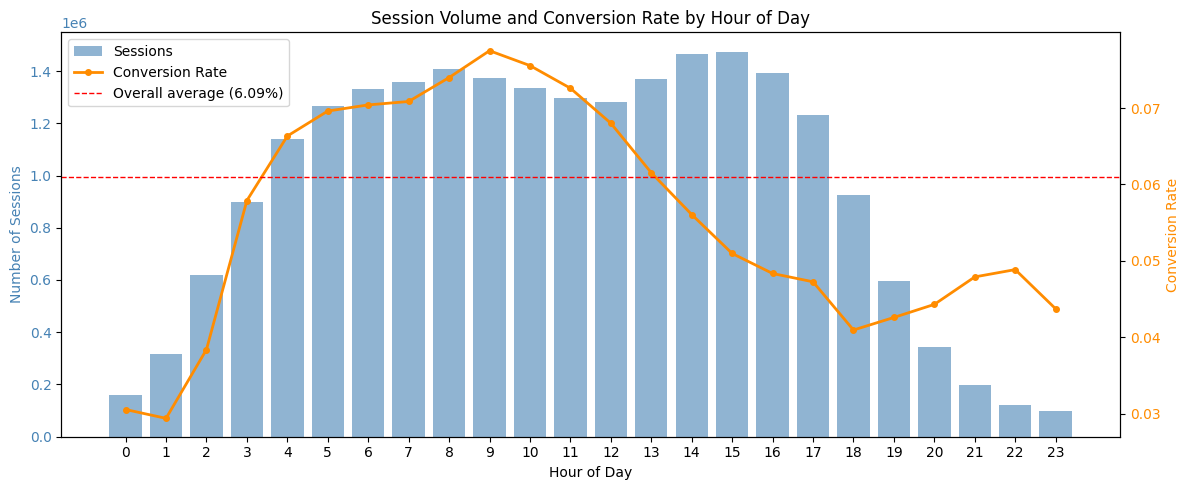

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart for session volume
ax1.bar(hourly_conversion['hour_of_day'], hourly_conversion['sessions'],
        color='steelblue', alpha=0.6, label='Sessions')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Sessions', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart for conversion rate on secondary axis
ax2 = ax1.twinx()
ax2.plot(hourly_conversion['hour_of_day'], hourly_conversion['conversion_rate'],
         color='darkorange', linewidth=2, marker='o', markersize=4, label='Conversion Rate')
ax2.axhline(y=overall_conversion_rate, color='red', linestyle='--', linewidth=1,
            label=f'Overall average ({overall_conversion_rate*100:.2f}%)')
ax2.set_ylabel('Conversion Rate', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_title('Session Volume and Conversion Rate by Hour of Day')
ax1.set_xticks(range(24))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/hourly_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

> Note: hour of day is a discrete category, the line connecting conversion rate points does not imply a continuous trend between them, it is used only to make the pattern easier to follow visually.

#### 1.3 Observations
* Conversion rate peaks in the morning hours: 9 am has the highest conversion rate at 7.75%, well above the 6.09% average
* Hours 4 through 12 all exceed the overall average conversion rate: morning and late morning are the best converting windows
* Session volume peaks later in the day (hours 13-15), but conversion rates are below average during these hours: the busiest hours are not the best converting hours
* Late night (hours 0-2) has both the lowest volume and the lowest conversion rates (3-4%): users browsing at midnight are much less likely to purchase
* This pattern makes sense: morning shoppers tend to have more real purchase intent, while afternoon/evening browsing is more casual
* These hourly patterns motivate the cateogory x hour lift facts computed later.

### 1.4 Conversion Rate by Day of Week
I examine how conversion rates vary across the days of the week.

In [8]:
# Define day order for correct sorting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_conversion = (
    session_df.groupby('day_of_week')['converted']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'conversions', 'count': 'sessions', 'mean': 'conversion_rate'})
    .reindex(day_order)
    .reset_index()
)

daily_conversion['conversion_rate_pct'] = (daily_conversion['conversion_rate'] * 100).round(2)

print(daily_conversion[['day_of_week', 'conversions', 'sessions', 'conversion_rate_pct']].to_string(index=False))

day_of_week  conversions  sessions  conversion_rate_pct
     Monday       171167   2919572                 5.86
    Tuesday       179057   3151361                 5.68
  Wednesday       183369   3118585                 5.88
   Thursday       178496   3185740                 5.60
     Friday       176421   3636044                 4.85
   Saturday       219095   3685579                 5.94
     Sunday       295153   3319769                 8.89


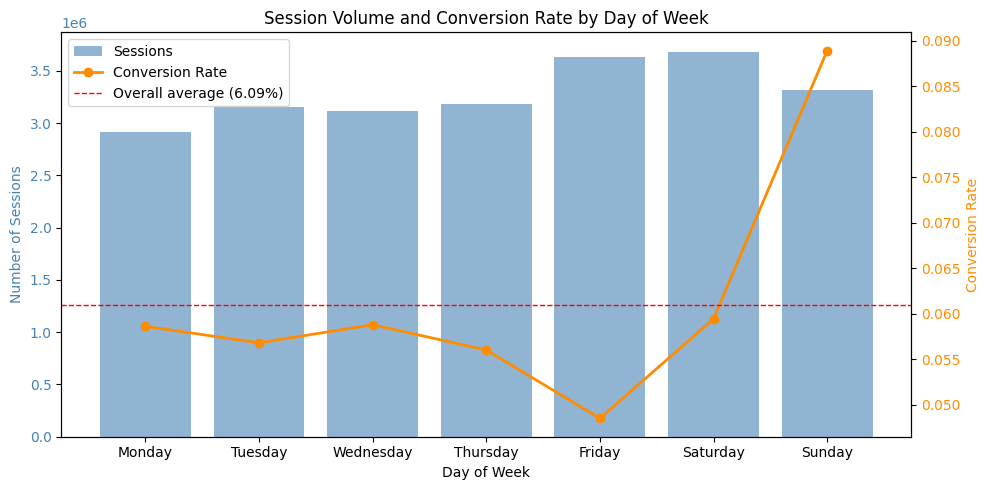

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(daily_conversion['day_of_week'], daily_conversion['sessions'],
        color='steelblue', alpha=0.6, label='Sessions')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Number of Sessions', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(daily_conversion['day_of_week'], daily_conversion['conversion_rate'],
         color='darkorange', linewidth=2, marker='o', markersize=6, label='Conversion Rate')
ax2.axhline(y=overall_conversion_rate, color='red', linestyle='--', linewidth=1,
            label=f'Overall average ({overall_conversion_rate*100:.2f}%)')
ax2.set_ylabel('Conversion Rate', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_title('Session Volume and Conversion Rate by Day of Week')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/daily_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

> Note: day of week is a discrete category, the line connecting 
conversion rate points does not imply a continuous trend between them, it is 
used only to make the pattern easier to follow visually.

#### 1.4 Observations
* Sunday has by the highest conversion rate at 8.89% (46% above the overall average of 6.09%)
* Friday has the lowest conversion rate at 4.85%. It is below average even though it is one of the highest volume days
* Monday through Thursday are all relatively consistent, right below the overall average (5.60% - 5.88%)
* Saturday shows a moderate increase (5.94%) into the Sunday peak
* The volume pattern is fairly flat across the week, with Friday and Saturday being the busiest days
* but Sunday converts significantly better even though lower volume
* The Sunday spike may reflect a shopping behavior of: users on Sundays may be making more planned purchases rather than casual browsing
* These day-of-week patterns motivate the category x day lift factors in future sections

### 1.5 Conversion Rate by Month
* I compare conversion rates between October and November to understand 
seasonal differences.
* This informs the seasonal lift factor computation later

In [10]:
monthly_conversion = (
    session_df.groupby('month')['converted']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'conversions', 'count': 'sessions', 'mean': 'conversion_rate'})
    .reset_index()
)

monthly_conversion['month_name'] = monthly_conversion['month'].map({10: 'October', 11: 'November'})
monthly_conversion['conversion_rate_pct'] = (monthly_conversion['conversion_rate'] * 100).round(2)

print(monthly_conversion[['month_name', 'conversions', 'sessions', 'conversion_rate_pct']].to_string(index=False))

month_name  conversions  sessions  conversion_rate_pct
   October       629572   9244421                 6.81
  November       773186  13772229                 5.61


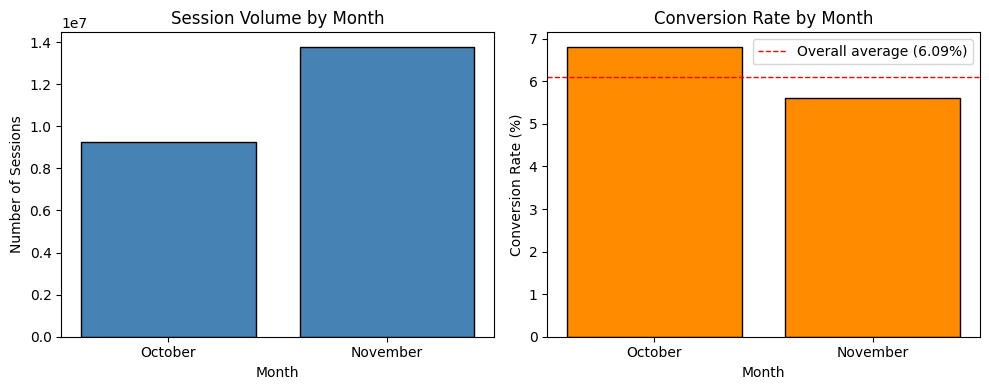

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Session volume
axes[0].bar(monthly_conversion['month_name'], monthly_conversion['sessions'],
            color='steelblue', edgecolor='black')
axes[0].set_title('Session Volume by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Sessions')

# Conversion rate
axes[1].bar(monthly_conversion['month_name'], monthly_conversion['conversion_rate_pct'],
            color='darkorange', edgecolor='black')
axes[1].axhline(y=overall_conversion_rate * 100, color='red', linestyle='--',
                linewidth=1, label=f'Overall average ({overall_conversion_rate*100:.2f}%)')
axes[1].set_title('Conversion Rate by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/monthly_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

#### 1.5 Observations
* October has a higher conversion rate (6.81%) than November (5.61%) even though November has way more sessions (13.8M vs 9.2M)
* October's conversion rate is above the overall average (6.09%), while November's is below it
* This suggests that November's higher session volume is driven by browsing 
behavior rather than purchase intent (users are more active but less likely to buy)
* The same drop in conversion was noted in notebook 1, possibly linked to holiday shopping patterns in late November, but we haven't checked this yet at the daily level
* I'll look at daily conversion rates within November later to see if specific dates stand out with unusually high purchase activity

---

## 2. Temporal Lift Factors

* I compute conversion lift factors for each hour of day, day of week, and date.
* The hour and day lift factors show the magnitude of temporal patterns in the data
* The seasonal lift factors are computed at the date level and directly used in re-ranking.
* Category-level lift factors for hour and day are computed later.
> Edit Note: the overall hour-of-day and day-of-week lift factors in sections 2.1 
and 2.2 are not directly used in re-ranking. At first I had these overall lift factors applied at the user level, but I changed my approach because I realized that multiplying all recommendations scores by the same factor doesn't chane the within-user ranking. So category-level lift factros were computed instead and are used in the final model. I kep these sections are motivating analysis and to show my learning process.

### 2.1 Hour-of-Day Lift Factors

In [12]:
hourly_lift = hourly_conversion.copy()
hourly_lift['lift_factor'] = hourly_lift['conversion_rate'] / overall_conversion_rate
hourly_lift['lift_factor'] = hourly_lift['lift_factor'].round(4)

print('--- Hour of Day Lift Factors ---')
print(hourly_lift[['hour_of_day', 'conversion_rate_pct', 'lift_factor']].to_string(index=False))

--- Hour of Day Lift Factors ---
 hour_of_day  conversion_rate_pct  lift_factor
           0                 3.05       0.5009
           1                 2.94       0.4820
           2                 3.84       0.6298
           3                 5.79       0.9500
           4                 6.63       1.0886
           5                 6.96       1.1423
           6                 7.04       1.1555
           7                 7.09       1.1628
           8                 7.40       1.2143
           9                 7.75       1.2720
          10                 7.56       1.2400
          11                 7.26       1.1914
          12                 6.80       1.1161
          13                 6.15       1.0097
          14                 5.61       0.9199
          15                 5.10       0.8363
          16                 4.83       0.7932
          17                 4.73       0.7754
          18                 4.09       0.6717
          19               

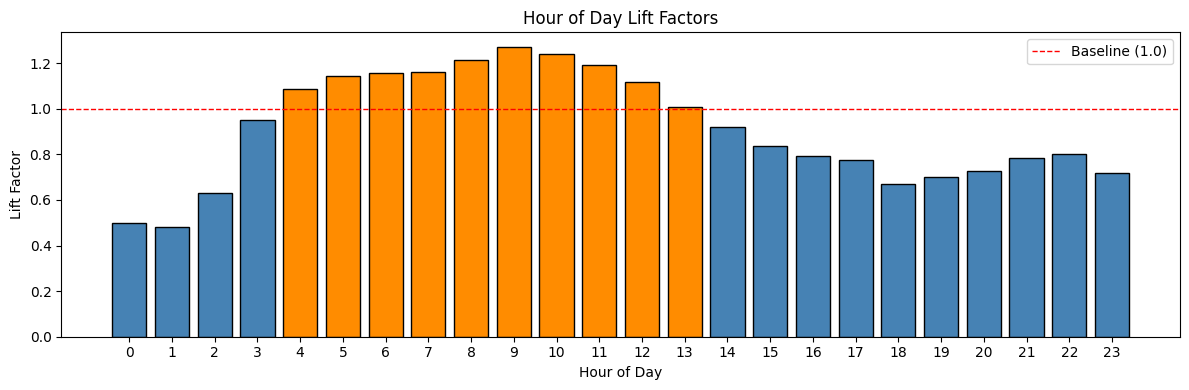

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = ['darkorange' if l >= 1.0 else 'steelblue' for l in hourly_lift['lift_factor']]

ax.bar(hourly_lift['hour_of_day'], hourly_lift['lift_factor'],
       color=colors, edgecolor='black')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Baseline (1.0)')
ax.set_title('Hour of Day Lift Factors')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Lift Factor')
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/hourly_lift.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.1 Observations
* Hours 4 through 13 have lift factors above 1.0 meaning morning hours convert better than average
* Hour 9 has the highest lift factor (1.27)
* Hours 0, 1, and 2 have the lowest lift factors (0.50, 0.48, 0.63) suggesting that late night browsing converts poorly

### 2.2 Day-of-Week Lift Factors

In [14]:
daily_lift = daily_conversion.copy()
daily_lift['lift_factor'] = daily_lift['conversion_rate'] / overall_conversion_rate
daily_lift['lift_factor'] = daily_lift['lift_factor'].round(4)

print('--- Day of Week Lift Factors ---')
print(daily_lift[['day_of_week', 'conversion_rate_pct', 'lift_factor']].to_string(index=False))

--- Day of Week Lift Factors ---
day_of_week  conversion_rate_pct  lift_factor
     Monday                 5.86       0.9620
    Tuesday                 5.68       0.9323
  Wednesday                 5.88       0.9648
   Thursday                 5.60       0.9193
     Friday                 4.85       0.7961
   Saturday                 5.94       0.9754
     Sunday                 8.89       1.4588


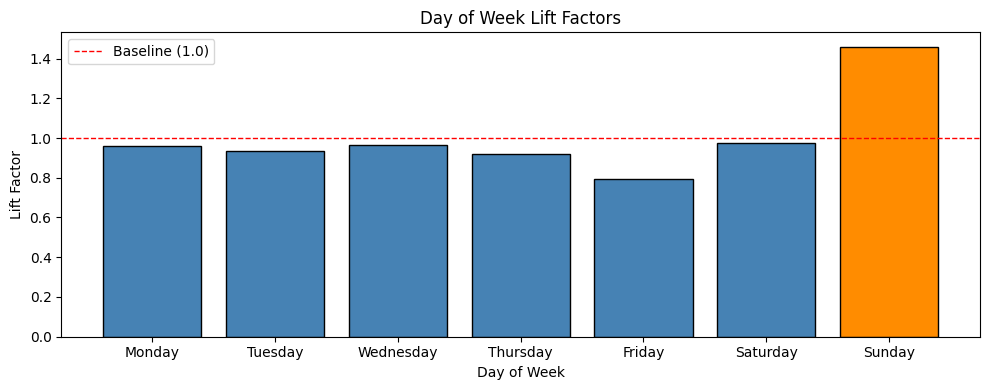

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['darkorange' if l >= 1.0 else 'steelblue' for l in daily_lift['lift_factor']]

ax.bar(daily_lift['day_of_week'], daily_lift['lift_factor'],
       color=colors, edgecolor='black')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Baseline (1.0)')
ax.set_title('Day of Week Lift Factors')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Lift Factor')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/daily_lift.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.2 Observations
* Sunday is the only day above the baseline with a lift factor of 1.46 meaning Sunday sessions convert 46% better on average
* Friday is the worst day with a lift factor of 0.80 meaning session convert 20% below avg
* Monday through Saturday (excluding Sunday) are all clustered just below 1.0 (0.79 - 0.98) and fairly consistent with each other

### 2.3 Seasonal Lift Factors

* I look at daily conversion rates within October and November to see if there are any dates with unusually high purchase activity

#### November Investigation

In [16]:
# Filter to November only and compute daily conversion rate
november_df = session_df[session_df['month'] == 11].copy()
november_df['date'] = november_df['session_start'].dt.date

daily_nov_conversion = (
    november_df.groupby('date')['converted']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'conversions', 'count': 'sessions', 'mean': 'conversion_rate'})
    .reset_index()
)

daily_nov_conversion['conversion_rate_pct'] = (daily_nov_conversion['conversion_rate'] * 100).round(2)
daily_nov_conversion['lift_factor'] = (daily_nov_conversion['conversion_rate'] / overall_conversion_rate).round(4)

print('--- Daily Conversion Rates in November ---')
print(daily_nov_conversion[['date', 'sessions', 'conversion_rate_pct', 'lift_factor']].to_string(index=False))

--- Daily Conversion Rates in November ---
      date  sessions  conversion_rate_pct  lift_factor
2019-11-01    319560                 6.01       0.9866
2019-11-02    337421                 5.58       0.9152
2019-11-03    342063                 5.60       0.9196
2019-11-04    395330                 5.90       0.9686
2019-11-05    374984                 5.70       0.9360
2019-11-06    365876                 5.89       0.9663
2019-11-07    394729                 5.42       0.8894
2019-11-08    442955                 4.99       0.8183
2019-11-09    408936                 4.79       0.7864
2019-11-10    416044                 4.75       0.7799
2019-11-11    461628                 4.61       0.7565
2019-11-12    452159                 4.27       0.7014
2019-11-13    457577                 4.18       0.6862
2019-11-14    560057                 3.34       0.5474
2019-11-15    763850                 0.00       0.0000
2019-11-16    991666                 5.71       0.9376
2019-11-17    975190  

* Most of November has lift factors below 1.0, consistent with the lower overall conversion rate we saw 
* Two dates stand out:
    * **November 15** — 991,666 sessions with a 0.00% conversion rate. Almost1 million sessions with zero purchases is not likely, most likely a data issue
    * **November 17** — 15.53% conversion rate and a lift factor of 2.55; the highest converting day in the dataset (12 days before Black Friday)
* **November 29 (Black Friday)** has a lift factor of only 1.01 (barely above average)
* I'll investigate November 15 and 17 before moving continuing to see if they show any important patterns or events

In [17]:
# Investigate November 15 and 17
for date in ['2019-11-15', '2019-11-16', '2019-11-17']:
    day_data = november_df[november_df['date'].astype(str) == date]
    print(f'--- {date} ---')
    print(f'Sessions: {len(day_data):,}')
    print(f'Conversions: {day_data["converted"].sum():,}')
    print(f'Conversion rate: {day_data["converted"].mean()*100:.2f}%')
    print(f'Avg session revenue: {day_data["session_revenue"].mean():.2f}')
    print()

--- 2019-11-15 ---
Sessions: 763,850
Conversions: 1
Conversion rate: 0.00%
Avg session revenue: 0.00

--- 2019-11-16 ---
Sessions: 991,666
Conversions: 56,664
Conversion rate: 5.71%
Avg session revenue: 23.64

--- 2019-11-17 ---
Sessions: 975,190
Conversions: 151,472
Conversion rate: 15.53%
Avg session revenue: 59.25



* Nothing unusual seems to happen on November 16 (between the two anomalies).
* Only 1 conversion on November 15
* November 15 also has a relatively high number of session compared to the previous days (seen in the output before the above), almost like a lead up to November 16 and 17, which have a high number of sessions.

In [18]:
# Look at hourly breakdown of Nov 15 to understand when single conversion was and sessions
nov15 = november_df[november_df['date'].astype(str) == '2019-11-15']

hourly_nov15 = (
    nov15.groupby(nov15['session_start'].dt.hour)['converted']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'conversions', 'count': 'sessions', 'mean': 'conversion_rate'})
    .reset_index()
    .rename(columns={'session_start': 'hour'})
)

print('--- November 15 Hourly Breakdown ---')
print(hourly_nov15.to_string(index=False))

--- November 15 Hourly Breakdown ---
 hour  conversions  sessions  conversion_rate
    0            0     12349         0.000000
    1            0     27918         0.000000
    2            1     47056         0.000021
    3            0     40746         0.000000
    4            0     35633         0.000000
    5            0     33196         0.000000
    6            0     31453         0.000000
    7            0     39732         0.000000
    8            0     47852         0.000000
    9            0     47667         0.000000
   10            0     45568         0.000000
   11            0     44451         0.000000
   12            0     39600         0.000000
   13            0     39567         0.000000
   14            0     35145         0.000000
   15            0     32111         0.000000
   16            0     30431         0.000000
   17            0     31142         0.000000
   18            0     30099         0.000000
   19            0     30138         0.0000

* Across all 24 hours of November 15, there is exactly 1 conversion total at hour 2
* The nuber of sessions acorss the hours seem reasonable
* Not a partial outage or a few missing hours, whatever happened affected the entire day uniformly
* Almost certainly a data collection issue

In [19]:
# Look at what drove the November 17 spike
nov17 = november_df[november_df['date'].astype(str) == '2019-11-17']

print('--- November 17 Hourly Breakdown ---')
hourly_nov17 = (
    nov17.groupby(nov17['session_start'].dt.hour)['converted']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'conversions', 'count': 'sessions', 'mean': 'conversion_rate'})
    .reset_index()
    .rename(columns={'session_start': 'hour'})
)
hourly_nov17['conversion_rate_pct'] = (hourly_nov17['conversion_rate'] * 100).round(2)
print(hourly_nov17[['hour', 'sessions', 'conversions', 'conversion_rate_pct']].to_string(index=False))

--- November 17 Hourly Breakdown ---
 hour  sessions  conversions  conversion_rate_pct
    0      4249            1                 0.02
    1      6590            7                 0.11
    2     18758           79                 0.42
    3     34688         2607                 7.52
    4     50714         7708                15.20
    5     62543         9337                14.93
    6     65211         9983                15.31
    7     63167         9808                15.53
    8     64694         9909                15.32
    9     64116         9813                15.31
   10     67600        11399                16.86
   11     70049        11935                17.04
   12     72510        12047                16.61
   13     67910        11734                17.28
   14     67823        11551                17.03
   15     61452        11013                17.92
   16     46321        10547                22.77
   17     41752         9613                23.02
   18     107

* Possibly a flash sale or promotional event that started around 3am and ended around 6pm
* The conversion rate of 22-23% at hours 16-17 is high (almost 4x overall average)
* Doesn't seem like random variation, it's a clear on/off pattern (like a timed promotion)

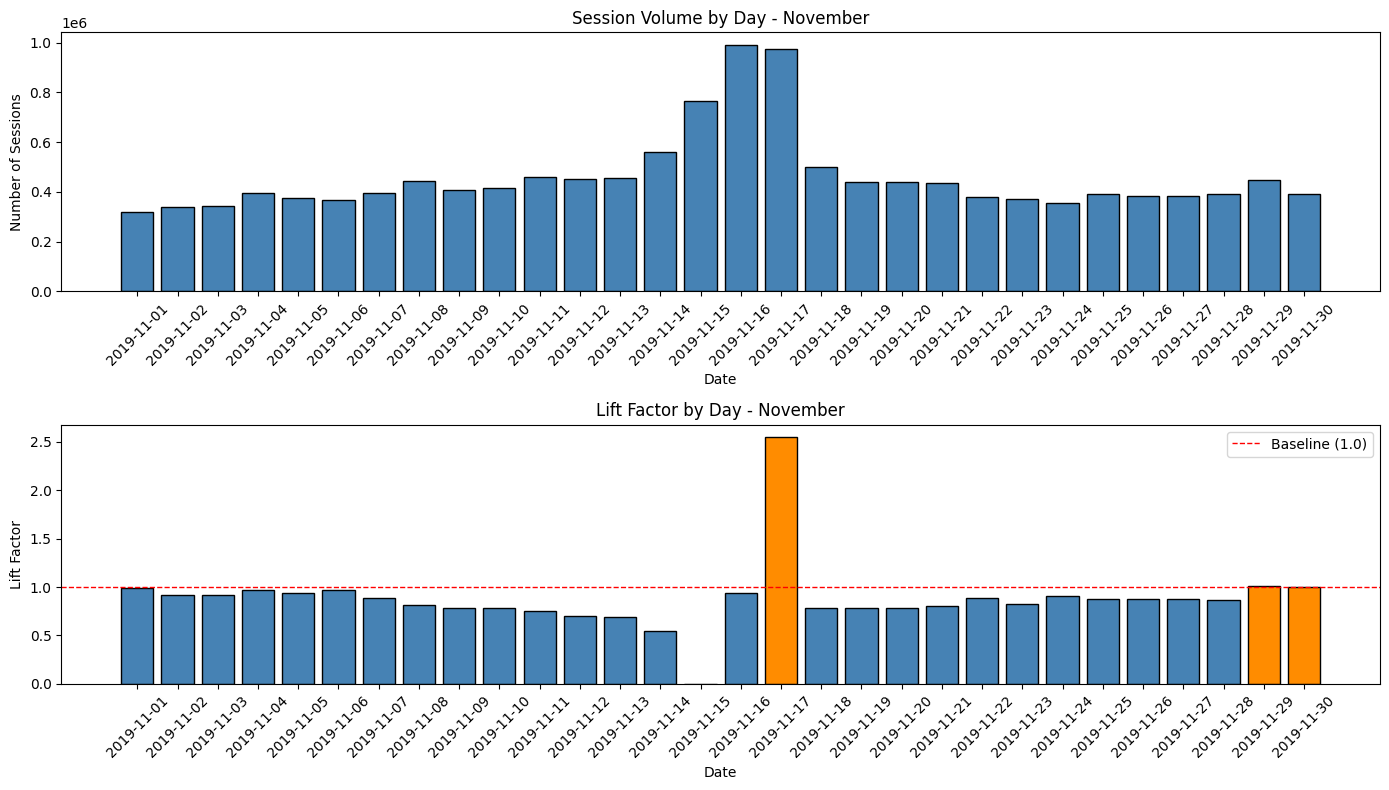

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Session volume
axes[0].bar(daily_nov_conversion['date'].astype(str), daily_nov_conversion['sessions'],
            color='steelblue', edgecolor='black')
axes[0].set_title('Session Volume by Day - November')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Sessions')
axes[0].tick_params(axis='x', rotation=45)

# Lift factor
axes[1].bar(daily_nov_conversion['date'].astype(str), daily_nov_conversion['lift_factor'],
            color=['darkorange' if l >= 1.0 else 'steelblue' for l in daily_nov_conversion['lift_factor']],
            edgecolor='black')
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Baseline (1.0)')
axes[1].set_title('Lift Factor by Day - November')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Lift Factor')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/november_daily_lift.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Compare Nov 17 revenue vs normal days
normal_days = november_df[
    ~november_df['date'].astype(str).isin(['2019-11-15', '2019-11-17'])
]

print('--- November 17 vs Normal November Days ---')
print(f'Nov 17 avg session revenue  : {nov17["session_revenue"].mean():.2f}')
print(f'Normal days avg session revenue: {normal_days["session_revenue"].mean():.2f}')
print(f'Nov 17 avg purchases per session: {nov17["n_purchases"].mean():.4f}')
print(f'Normal days avg purchases per session: {normal_days["n_purchases"].mean():.4f}')
print(f'Nov 17 avg order value (converted sessions only): {nov17[nov17["converted"]]["session_revenue"].mean():.2f}')
print(f'Normal days avg order value (converted sessions only): {normal_days[normal_days["converted"]]["session_revenue"].mean():.2f}')

--- November 17 vs Normal November Days ---
Nov 17 avg session revenue  : 59.25
Normal days avg session revenue: 18.06
Nov 17 avg purchases per session: 0.1899
Normal days avg purchases per session: 0.0608
Nov 17 avg order value (converted sessions only): 381.43
Normal days avg order value (converted sessions only): 349.64


* Nov 17 average session revenue is ~3x higher
* Average order value for converted sessions is slightly high but not dramatically different
* Nov 17 purchases per session are 0.19 vs 0.06 (3x more purchases)
* Spike isn't from cheap items; people are buying roughly the same value items, but buying a lot more of them.
* Combined with the hourly pattern showing on/off switch at hours 3 and 18, suggests a timed promotional event  

Other considerations:
* **Pre-Black Friday sales**: "Black November" early deals sometimes start around November 17, but we would expect to see similar, if not higher, conversion rates on actual Black Friday.
* **COVID-19**: On November 17, 2019, the first case of COVID-19 was identified in China. But panic buying and behavioral shifts didn't happen until early 2020 when the virus spread internationally. It's unlikely that it influenced an e-commerce site, too.

#### October Investigation

In [22]:
# Check daily conversion rates in October
october_df = session_df[session_df['month'] == 10].copy()
october_df['date'] = october_df['session_start'].dt.date

daily_oct_conversion = (
    october_df.groupby('date')['converted']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'conversions', 'count': 'sessions', 'mean': 'conversion_rate'})
    .reset_index()
)

daily_oct_conversion['conversion_rate_pct'] = (daily_oct_conversion['conversion_rate'] * 100).round(2)
daily_oct_conversion['lift_factor'] = (daily_oct_conversion['conversion_rate'] / overall_conversion_rate).round(4)

print('--- Daily Conversion Rates in October ---')
print(daily_oct_conversion[['date', 'sessions', 'conversion_rate_pct', 'lift_factor']].to_string(index=False))

--- Daily Conversion Rates in October ---
      date  sessions  conversion_rate_pct  lift_factor
2019-10-01    268737                 6.05       0.9927
2019-10-02    260229                 6.31       1.0351
2019-10-03    239905                 6.74       1.1052
2019-10-04    299357                 7.66       1.2575
2019-10-05    275608                 7.13       1.1696
2019-10-06    271638                 6.93       1.1375
2019-10-07    261891                 6.89       1.1306
2019-10-08    306808                 6.38       1.0475
2019-10-09    299698                 6.44       1.0572
2019-10-10    293583                 6.35       1.0424
2019-10-11    331807                 6.69       1.0973
2019-10-12    302895                 7.13       1.1707
2019-10-13    332001                 7.59       1.2457
2019-10-14    306159                 7.89       1.2941
2019-10-15    333204                 6.72       1.1029
2019-10-16    327481                 8.09       1.3279
2019-10-17    301783   

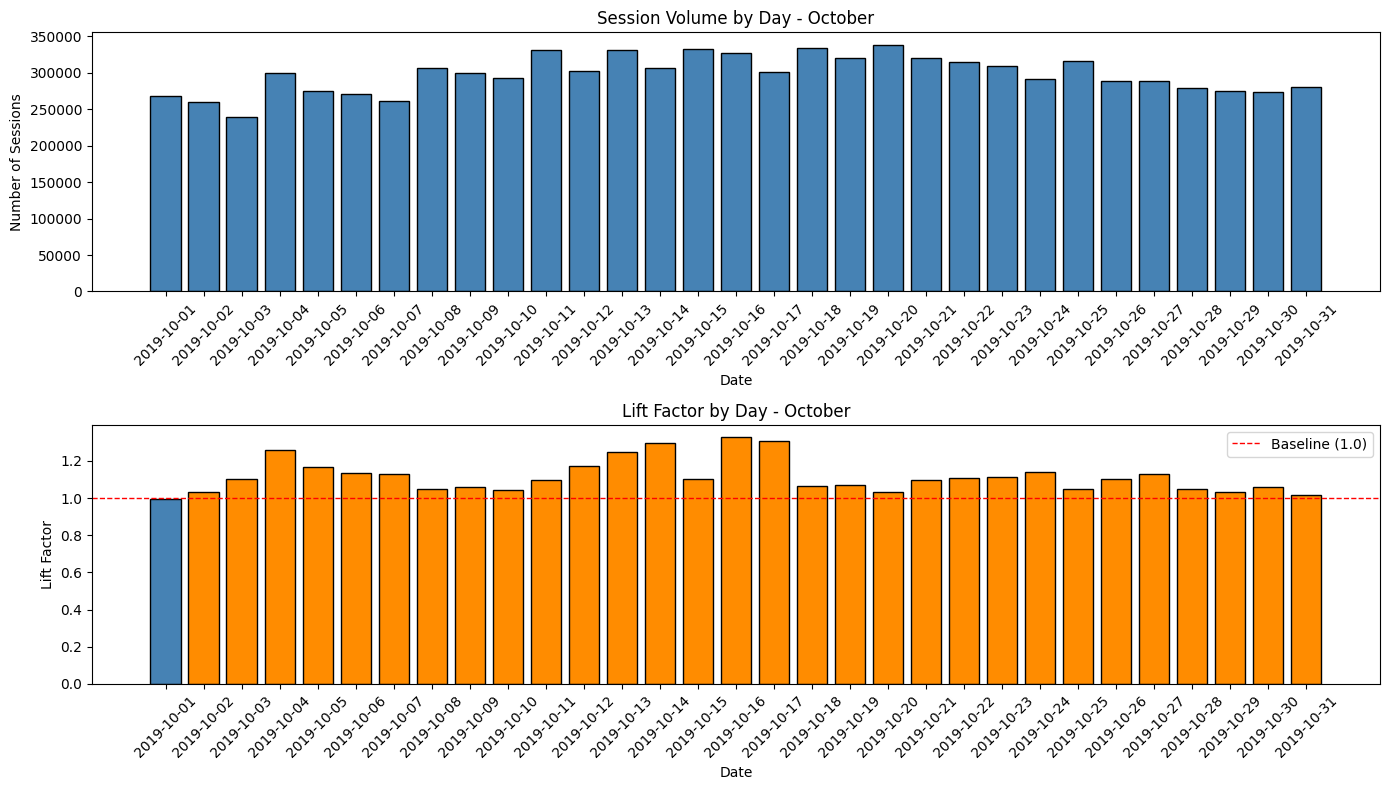

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Session volume
axes[0].bar(daily_oct_conversion['date'].astype(str), daily_oct_conversion['sessions'],
            color='steelblue', edgecolor='black')
axes[0].set_title('Session Volume by Day - October')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Sessions')
axes[0].tick_params(axis='x', rotation=45)

# Lift factor
axes[1].bar(daily_oct_conversion['date'].astype(str), daily_oct_conversion['lift_factor'],
            color=['darkorange' if l >= 1.0 else 'steelblue' for l in daily_oct_conversion['lift_factor']],
            edgecolor='black')
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Baseline (1.0)')
axes[1].set_title('Lift Factor by Day - October')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Lift Factor')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/october_daily_lift.png', dpi=300, bbox_inches='tight')
plt.show()

#### October Daily Observations
* Session volume is consistent across October, no days with unusually high or low traffic
* Almost all days have lift factors above 1.0. So October generally converts better than the overall average
* The highest lift factor is October 16 (1.33) and October 17 (1.31) which is slightly higher but nothing extreme compared to November 17 (2.55)
* No data anomalies like November 15. October looks clean throughout
* No individual October dates need special treatment. So, October will be treated as a single aggregate in the seasonal lift computation

#### 2.3 Observations/Notes
* November 15 is excluded from seasonal lift factor computation; it had only 1 conversion across 763,850 sessions, confirmed as a data collection failure
* November 17 is kept: the spike reflects a genuine promotional event, not a data artifact
* November 29 (Black Friday) has a lift factor of only 1.01; barely above average, so no special treatment is needed for that date
* October is treated as a single aggregate lift factor of 1.12; no individual dates showed unusual patterns, so daily lift factors are not needed for October
  
> Edit Note: I made the original deicsion to avoid further complexity, however in the future I would adjust October on specific dates for consistency. 

#### Compute seasonal lift factors
* Used in re-reranking later

In [24]:
# November — daily, excluding Nov 15
seasonal_lift_nov = daily_nov_conversion[
    daily_nov_conversion['date'].astype(str) != '2019-11-15'
].copy()
seasonal_lift_nov['lift_factor'] = (
    seasonal_lift_nov['conversion_rate'] / overall_conversion_rate
).round(4)

# October — single aggregate lift factor
oct_conversion_rate = october_df['converted'].mean()
oct_lift_factor = round(oct_conversion_rate / overall_conversion_rate, 4)

print(f'October aggregate conversion rate: {oct_conversion_rate*100:.2f}%')
print(f'October aggregate lift factor    : {oct_lift_factor}')
print(f'\nNovember daily lift factors (excluding Nov 15):')
print(seasonal_lift_nov[['date', 'conversion_rate_pct', 'lift_factor']].to_string(index=False))

October aggregate conversion rate: 6.81%
October aggregate lift factor    : 1.1174

November daily lift factors (excluding Nov 15):
      date  conversion_rate_pct  lift_factor
2019-11-01                 6.01       0.9866
2019-11-02                 5.58       0.9152
2019-11-03                 5.60       0.9196
2019-11-04                 5.90       0.9686
2019-11-05                 5.70       0.9360
2019-11-06                 5.89       0.9663
2019-11-07                 5.42       0.8894
2019-11-08                 4.99       0.8183
2019-11-09                 4.79       0.7864
2019-11-10                 4.75       0.7799
2019-11-11                 4.61       0.7565
2019-11-12                 4.27       0.7014
2019-11-13                 4.18       0.6862
2019-11-14                 3.34       0.5474
2019-11-16                 5.71       0.9376
2019-11-17                15.53       2.5486
2019-11-18                 4.79       0.7856
2019-11-19                 4.78       0.7837
2019-11-20   

* October has an aggregate lift factor of 1.12 meaning October sessions convert about 12% better than the overall average
* Most November days have lift factors below 1.0, consistent with what we saw earlier
* November 17 stands out with a lift factor of 2.55: the only November date significantly above average
* November 29 and 30 are just barely above 1.0, no meaningful Black Friday effect was found in the data

---

## 3. Re-ranking Recommendations

* I load the baseline recommendations from notebook 06 and re-rank them using the combined temporal lift factor.
* For each recommendation, the original predicted score is multiplied by the combined lift factor to produce a temporal score.
* Recommendations are then re-ranked by temporal score.

The combined lift factor is computed as:
```
temporal_score = predicted_score x cat_hour_lift x day_lift x seasonal_lift
```

### 3.1 Load Baseline Recommendations

In [25]:
recommendations_df = pd.read_parquet(RECOMMENDATIONS_FILE)

print(f'Shape: {recommendations_df.shape}')
print(f'Users: {recommendations_df["user_id"].nunique():,}')
print(f'\nFirst 10 rows:')
print(recommendations_df.head(10).to_string(index=False))

Shape: (11138954, 4)
Users: 2,227,793

First 10 rows:
 user_id recommended_category  predicted_score  rank
29515875            furniture           0.1600     1
29515875          accessories           0.1367     2
29515875                 auto           0.1330     3
29515875         construction           0.1279     4
29515875              apparel           0.1230     5
31198833            furniture           0.5760     1
31198833          accessories           0.4923     2
31198833                 auto           0.4790     3
31198833         construction           0.4603     4
31198833              apparel           0.4428     5


* 11,138,954 recommendations across 2,227,793 users: matches notebook 06 output exactly
* Each user has up to 5 recommendations ranked by predicted score

### 3.2 User Temporal Context

* For each user, I extract their most recent session's hour of day, day of week, and date (rather than picking an arbitrary time)
* These are used to determine which lift factors to apply when re-ranking their recommendations.

In [26]:
# Get each user's most recent session
user_temporal = (
    # sort chronologically so the last session per user is the most recent one
    session_df.sort_values('session_start')
    # take most recent session (last row per user)
    .groupby('user_id')
    .last()
    .reset_index()
[['user_id', 'hour_of_day', 'day_of_week', 'session_start', 'month']]
)

user_temporal['date'] = user_temporal['session_start'].dt.date

print(f'Users with temporal context: {len(user_temporal):,}')
print(f'\nFirst 5 rows:')
print(user_temporal[['user_id', 'hour_of_day', 'day_of_week', 'date', 'month']].head().to_string(index=False))

Users with temporal context: 5,316,560

First 5 rows:
 user_id  hour_of_day day_of_week       date  month
10300217            6   Wednesday 2019-11-06     11
29515875           15   Wednesday 2019-11-20     11
31198833            1     Tuesday 2019-11-19     11
33869381           20   Wednesday 2019-10-23     10
34916060            7      Sunday 2019-11-24     11


* 5,316,560 users have temporal context from their most recent session
* This covers more users than are in the recommendations file (2,227,793). This is because of the minimum affinity threshold applied in notebook 6.
* Users without recommendations will be naturally filtering out when joining later on
* Users have a mix of October and November last sessions

### 3.3 Category-Level Temporal Lift Factors

* I compute lift factors at the category x hour and category x day level, capturing whether specific categories convert better or worse at specific times.
* I use the affinity data to identify which categories each user purchased from, then join with session data to get the time context of those purchases.

> Edit Note: As mention in previous notes, the initial approach applied a single lift factor per user, which scaled all recommendation scores equally and did not change the within-user ranking. I use the approach above to actually re-rank recommendations

In [27]:
# Load affinity data (only need users who made at least one purchase)
affinity_df = pd.read_parquet(AFFINITY_FILE)

# Filter to users with at least one purchase in a category
purchased = affinity_df[affinity_df['cat_purchases'] > 0][['user_id', 'main_category']]

print(f'User-category purchase pairs: {len(purchased):,}')
print(f'Unique users who purchased  : {purchased["user_id"].nunique():,}')
print(f'Unique categories           : {purchased["main_category"].nunique()}')
print(f'\nFirst 5 rows:')
print(purchased.head().to_string(index=False))

User-category purchase pairs: 617,837
Unique users who purchased  : 549,644
Unique categories           : 13

First 5 rows:
  user_id main_category
225644257     computers
253299396    appliances
256164170    appliances
296197073          auto
299358698   electronics


* 617,837 user-category purchase pairs across 549,644 unique users
* Only users with at least one confirmed purchase are kept because this is the strongest signal of genuine category preference
* All 13 categories are represented

In [28]:
# Join purchased categories with session data to get time context
# Use converted sessions only, these are sessions that ended in a purchase
converted_sessions = session_df[session_df['converted'] == True][
    ['user_id', 'hour_of_day', 'day_of_week', 'month']
]

# Join: for each user who purchased a category, get their converted session times
category_time = purchased.merge(converted_sessions, on='user_id', how='inner')

print(f'Category-time pairs: {len(category_time):,}')
print(f'\nFirst 5 rows:')
print(category_time.head().to_string(index=False))

Category-time pairs: 1,616,474

First 5 rows:
  user_id main_category  hour_of_day day_of_week  month
225644257     computers            4     Tuesday     11
253299396    appliances           10   Wednesday     11
256164170    appliances            8   Wednesday     11
296197073          auto            8    Saturday     11
296197073          auto           11    Saturday     11


* 1,616,474 category-time pairs after joining purchase data with converted sessions
* Each row represents a user who purchased from a category, paired with the time of one of their converted sessions
* This gives the data needed to compute how each category's purchases distribute across hours and days

#### Computing category x hour lift factors and checking electronics

In [29]:
# Compute category x hour lift factors
cat_hour_conversion = (
    category_time.groupby(['main_category', 'hour_of_day'])
    .size()
    .reset_index(name='purchases')
)

# Total purchases per category
cat_total = cat_hour_conversion.groupby('main_category')['purchases'].transform('sum')
cat_hour_conversion['purchase_rate'] = cat_hour_conversion['purchases'] / cat_total

# Overall purchase rate per hour across all categories
hour_total = cat_hour_conversion.groupby('hour_of_day')['purchases'].transform('sum')
overall_hour_rate = cat_hour_conversion.groupby('hour_of_day')['purchases'].sum() / len(category_time)

# Lift = category purchase rate at this hour / overall purchase rate at this hour
cat_hour_conversion['hour_baseline'] = cat_hour_conversion['hour_of_day'].map(
    overall_hour_rate
)
cat_hour_conversion['lift_factor'] = (
    cat_hour_conversion['purchase_rate'] / cat_hour_conversion['hour_baseline']
).round(4)

print('--- Category x Hour Lift Factors (sample) ---')
print(cat_hour_conversion[
    cat_hour_conversion['main_category'] == 'electronics'
][['main_category', 'hour_of_day', 'purchases', 'lift_factor']].to_string(index=False))

--- Category x Hour Lift Factors (sample) ---
main_category  hour_of_day  purchases  lift_factor
  electronics            0       3480       0.9713
  electronics            1       6215       0.9492
  electronics            2      15329       0.9503
  electronics            3      34485       0.9776
  electronics            4      50154       0.9846
  electronics            5      59298       0.9959
  electronics            6      63790       1.0096
  electronics            7      65857       1.0079
  electronics            8      71176       1.0161
  electronics            9      73164       1.0185
  electronics           10      69441       1.0147
  electronics           11      65147       1.0168
  electronics           12      60406       1.0147
  electronics           13      57852       1.0017
  electronics           14      55722       0.9953
  electronics           15      50572       0.9772
  electronics           16      45118       0.9657
  electronics           17      3965

* Electronics lift factors are almost flat (small range), it doesn't strongly prefer any particular hour, consistent with it being a universally popular category
* To see whether other categories show more meaningful variation, I compare the ranges across all 13 categories:

In [30]:
# Compute range for all 13 categories
cat_hour_range = (
    cat_hour_conversion.groupby('main_category')['lift_factor']
    .agg(['min', 'max'])
    .reset_index()
)
cat_hour_range['range'] = (cat_hour_range['max'] - cat_hour_range['min']).round(3)
cat_hour_range = cat_hour_range.sort_values('range', ascending=False).reset_index(drop=True)

print('--- Category x Hour Lift Factor Range (all categories) ---')
print(cat_hour_range.to_string(index=False))

--- Category x Hour Lift Factor Range (all categories) ---
main_category    min    max  range
   stationery 0.5347 2.7405  2.206
 country_yard 0.2686 2.3292  2.061
     medicine 0.2946 1.6106  1.316
        sport 0.8842 1.5329  0.649
      apparel 0.8958 1.4763  0.580
 construction 0.6770 1.2560  0.579
  accessories 0.8613 1.3407  0.479
         kids 0.8418 1.2733  0.432
   appliances 0.6662 1.0452  0.379
    furniture 0.8384 1.1893  0.351
    computers 0.9607 1.2434  0.283
         auto 0.9167 1.1823  0.266
  electronics 0.9492 1.0677  0.119


In [31]:
# Total purchases per category to assess reliability
cat_purchase_totals = (
    cat_hour_conversion.groupby('main_category')['purchases']
    .sum()
    .reset_index()
    .rename(columns={'purchases': 'total_purchases'})
    .sort_values('total_purchases', ascending=False)
)

print('--- Total Purchases per Category ---')
print(cat_purchase_totals.to_string(index=False))

--- Total Purchases per Category ---
main_category  total_purchases
  electronics           960791
   appliances           294445
    computers           121667
      apparel            56129
    furniture            47627
         auto            46677
 construction            36568
         kids            29912
  accessories            12072
        sport             7722
     medicine             1960
   stationery              589
 country_yard              315


* Stationery (range 2.206) and country_yard (range 2.061) show the most variation, but these are the sparsest categories with only 315 and 589 total purchases; their extreme ranges are statistical noise from small sample sizes
* Sport (0.649) and apparel (0.580) show meaningful variation backed by 7,722 and 56,129 purchases
* Electronics (0.119) is the flattest, its dominance means it doesn't skew toward any particular time
* The bottom 3 categories (medicine, stationery, country_yard) have too few purchases to produce reliable temporal lift factors
* These categories will have their lift factors smoothed toward 1.0 using shrinkage weighting in the next step, similar to the approach used for the similarity matrix in notebook 06

#### Category hour visualizations

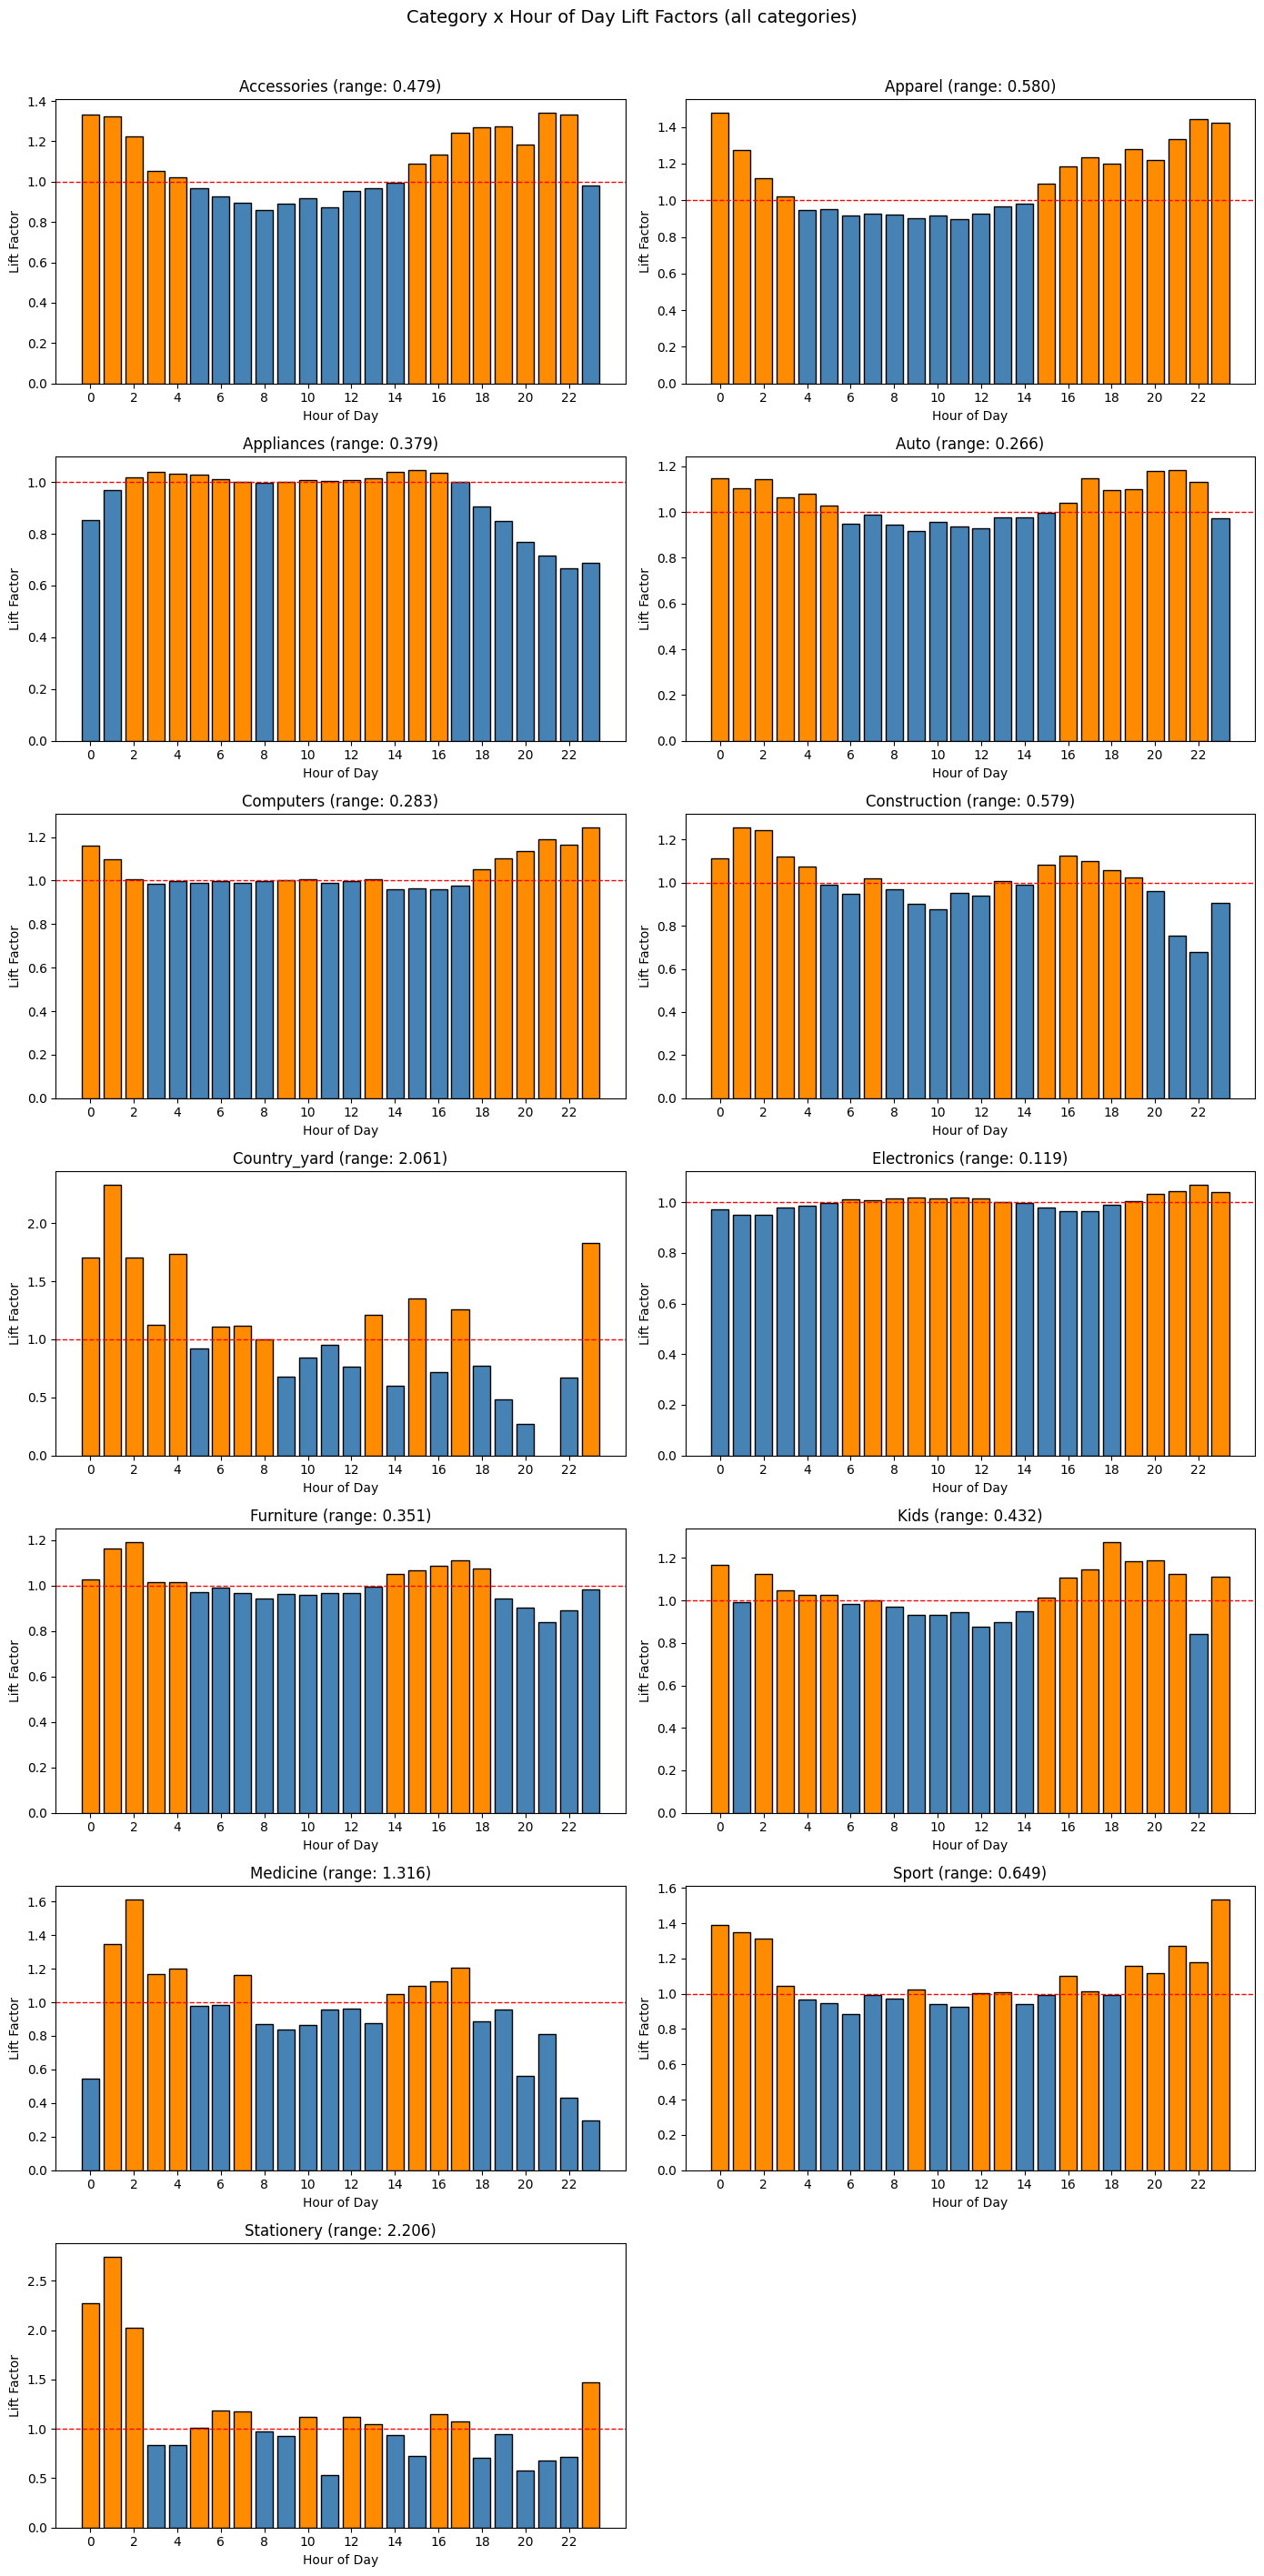

In [32]:
categories = sorted(cat_hour_conversion['main_category'].unique())
n_cats = len(categories)

fig, axes = plt.subplots(7, 2, figsize=(14, 28))
axes_flat = axes.flatten()

for i, cat in enumerate(categories):
    cat_data = cat_hour_conversion[cat_hour_conversion['main_category'] == cat]
    colors = ['darkorange' if l >= 1.0 else 'steelblue' for l in cat_data['lift_factor']]
    axes_flat[i].bar(cat_data['hour_of_day'], cat_data['lift_factor'],
                     color=colors, edgecolor='black')
    axes_flat[i].axhline(y=1.0, color='red', linestyle='--', linewidth=1)
    axes_flat[i].set_title(f'{cat.capitalize()} (range: {cat_data["lift_factor"].max() - cat_data["lift_factor"].min():.3f})')
    axes_flat[i].set_xlabel('Hour of Day')
    axes_flat[i].set_ylabel('Lift Factor')
    axes_flat[i].set_xticks(range(0, 24, 2))

# Hide the last empty subplot (13 categories = 7x2 grid, last spot empty)
axes_flat[-1].set_visible(False)

plt.suptitle('Category x Hour of Day Lift Factors (all categories)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/category_hour_lift_all.png', dpi=300, bbox_inches='tight')
plt.show()

* Sport (0.649), apparel (0.580), and construction (0.579) show the most meaningful variation among well-supported categories
* Apparel and accessories peaks at midnight and late evening, suggesting late-night fashion browsing converts well
* Sport peaks at hour 22-23 (lift 1.53), also an evening pattern
* Kids peaks early morning and late evening, may suggest parents shopping outside of work hours
* Appliances converts best in the morning and drops off significantly in the evening
* Country_yard, medicine, and stationery show extreme ranges (2.061, 1.316, 2.206) but these are driven by small sample sizes. Their patterns are unreliable and will be smoothed in the next step

#### Compute category x day lift factors

In [33]:
# Compute category x day lift factors
cat_day_conversion = (
    category_time.groupby(['main_category', 'day_of_week'])
    .size()
    .reset_index(name='purchases')
)

# Total purchases per category
cat_total_day = cat_day_conversion.groupby('main_category')['purchases'].transform('sum')
cat_day_conversion['purchase_rate'] = cat_day_conversion['purchases'] / cat_total_day

# Overall purchase rate per day across all categories
overall_day_rate = cat_day_conversion.groupby('day_of_week')['purchases'].sum() / len(category_time)

# Lift = category purchase rate at this day / overall purchase rate at this day
cat_day_conversion['day_baseline'] = cat_day_conversion['day_of_week'].map(overall_day_rate)
cat_day_conversion['lift_factor'] = (
    cat_day_conversion['purchase_rate'] / cat_day_conversion['day_baseline']
).round(4)

# Compute range for all categories
cat_day_range = (
    cat_day_conversion.groupby('main_category')['lift_factor']
    .agg(['min', 'max'])
    .reset_index()
)
cat_day_range['range'] = (cat_day_range['max'] - cat_day_range['min']).round(3)
cat_day_range = cat_day_range.sort_values('range', ascending=False).reset_index(drop=True)

print('--- Category x Day Lift Factor Range (all categories) ---')
print(cat_day_range.to_string(index=False))

--- Category x Day Lift Factor Range (all categories) ---
main_category    min    max  range
 country_yard 0.6743 1.3657  0.691
   appliances 0.9359 1.1419  0.206
  accessories 0.9085 1.1105  0.202
    furniture 0.9384 1.1265  0.188
         kids 0.9044 1.0751  0.171
     medicine 0.9167 1.0633  0.147
   stationery 0.9272 1.0709  0.144
        sport 0.9310 1.0634  0.132
 construction 0.9619 1.0653  0.103
      apparel 0.9619 1.0456  0.084
  electronics 0.9550 1.0195  0.065
         auto 0.9659 1.0287  0.063
    computers 0.9836 1.0228  0.039


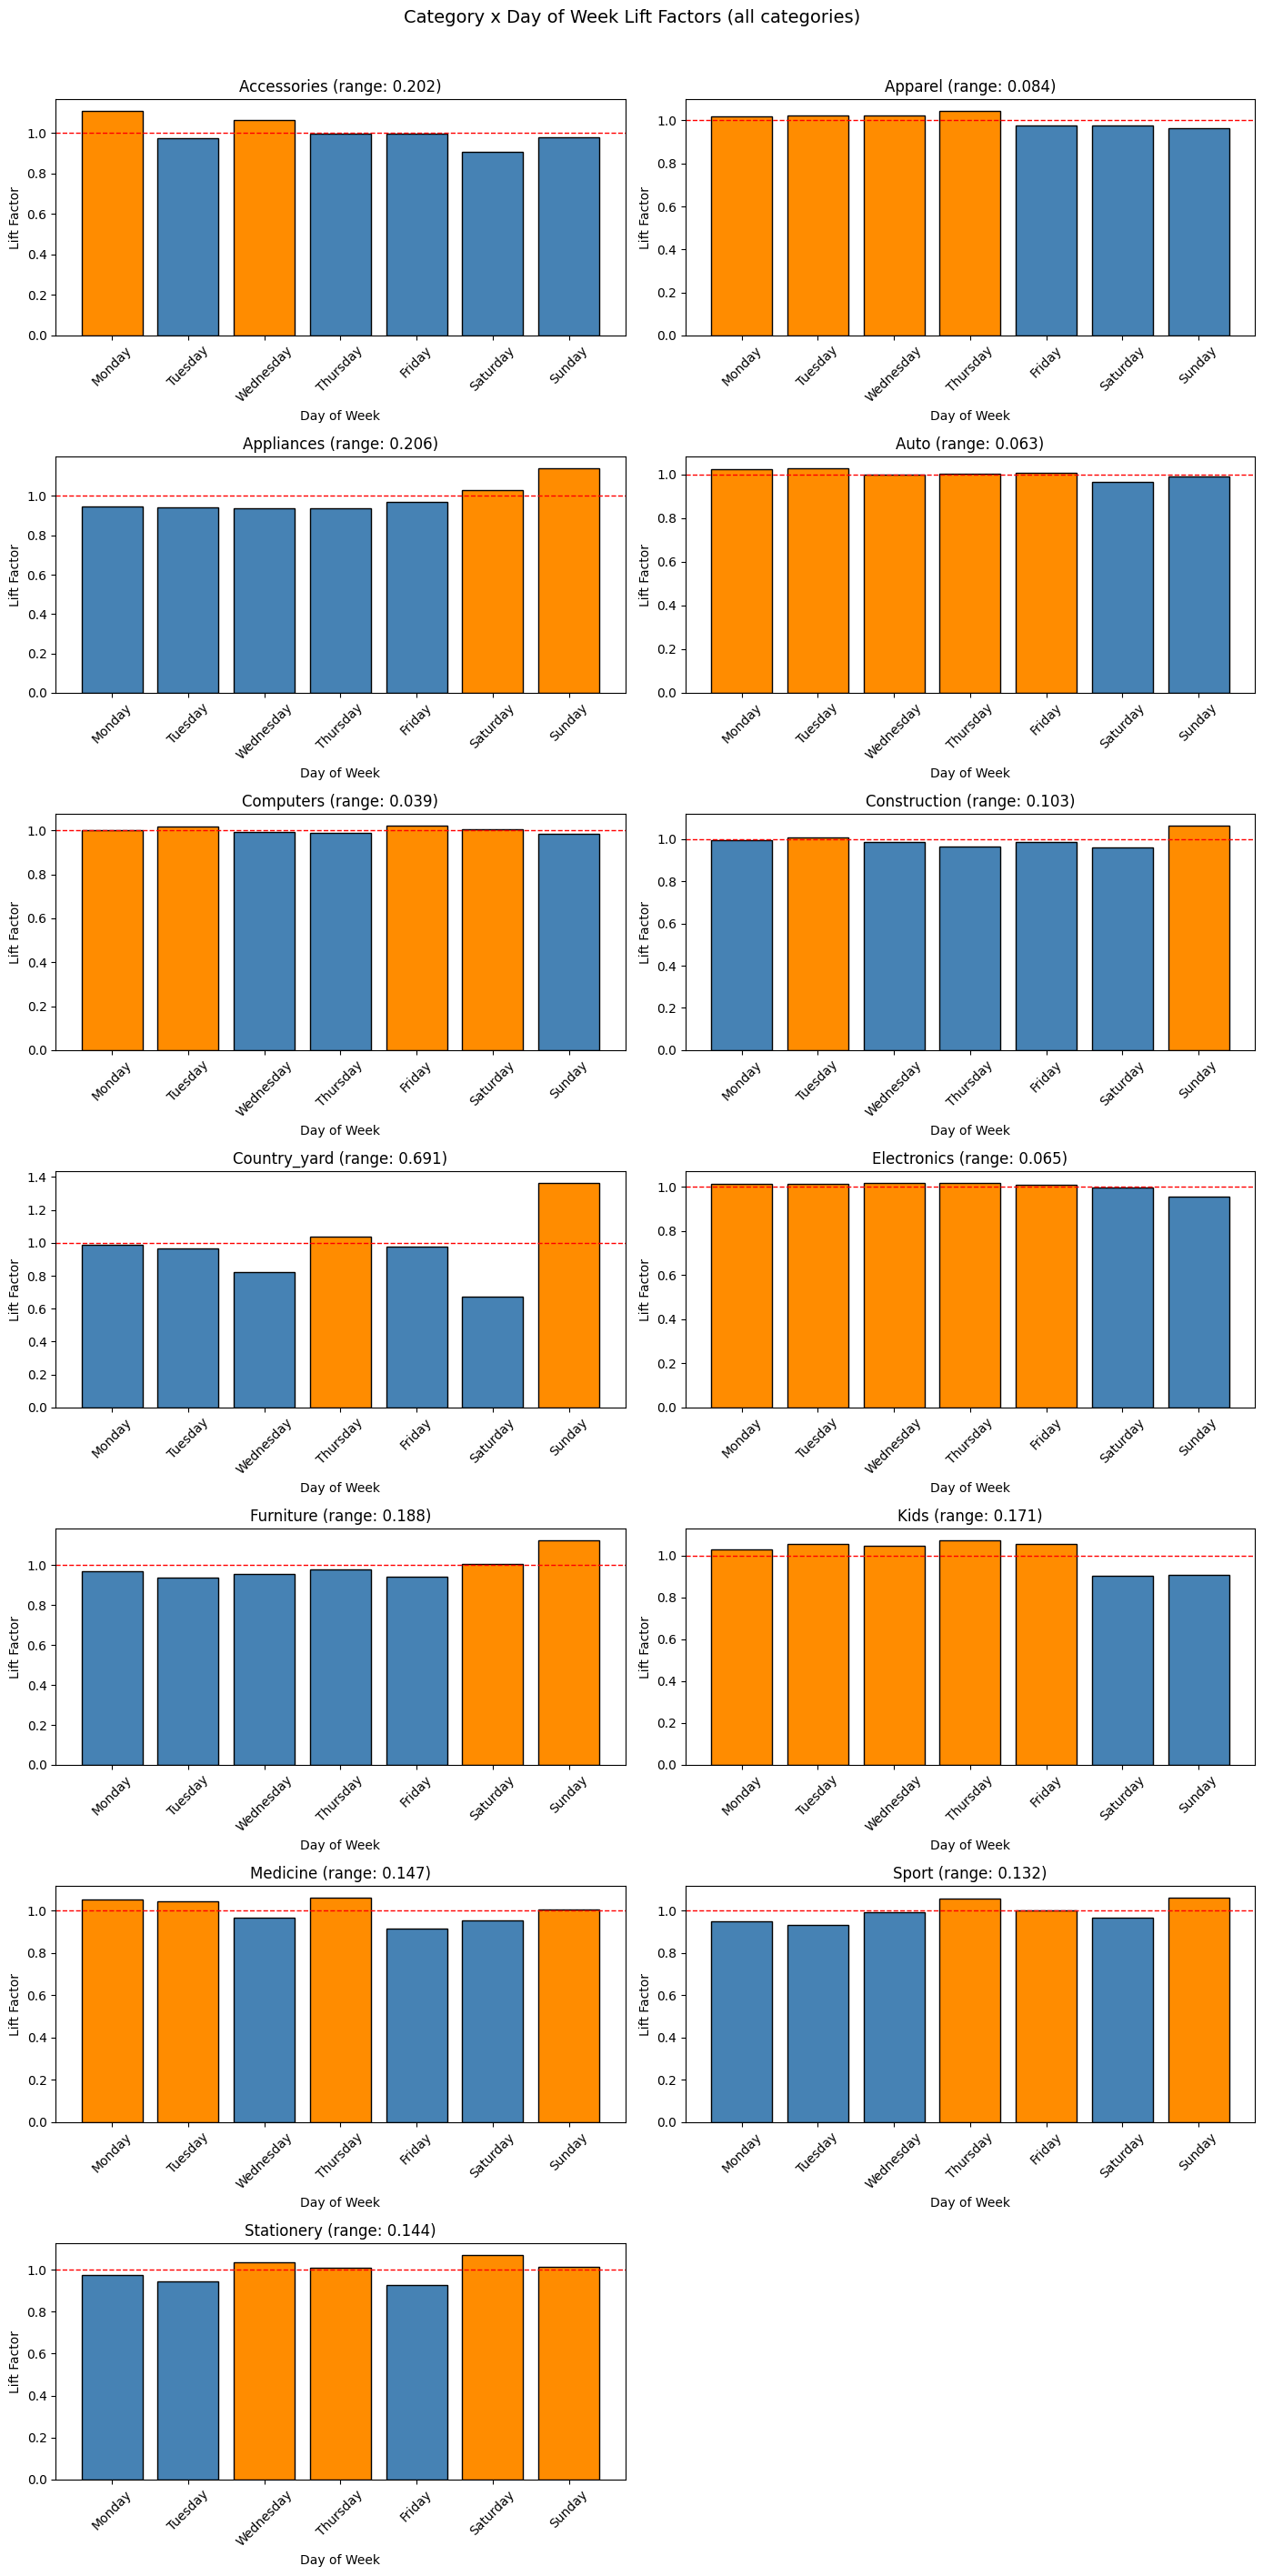

In [34]:
# Reorder days correctly
cat_day_conversion['day_of_week'] = pd.Categorical(
    cat_day_conversion['day_of_week'],
    categories=day_order,
    ordered=True
)
cat_day_conversion = cat_day_conversion.sort_values(['main_category', 'day_of_week'])

fig, axes = plt.subplots(7, 2, figsize=(14, 28))
axes_flat = axes.flatten()

for i, cat in enumerate(categories):
    cat_data = cat_day_conversion[cat_day_conversion['main_category'] == cat]
    colors = ['darkorange' if l >= 1.0 else 'steelblue' for l in cat_data['lift_factor']]
    axes_flat[i].bar(cat_data['day_of_week'], cat_data['lift_factor'],
                     color=colors, edgecolor='black')
    axes_flat[i].axhline(y=1.0, color='red', linestyle='--', linewidth=1)
    axes_flat[i].set_title(f'{cat.capitalize()} (range: {cat_data["lift_factor"].max() - cat_data["lift_factor"].min():.3f})')
    axes_flat[i].set_xlabel('Day of Week')
    axes_flat[i].set_ylabel('Lift Factor')
    axes_flat[i].tick_params(axis='x', rotation=45)

axes_flat[-1].set_visible(False)

plt.suptitle('Category x Day of Week Lift Factors (all categories)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/category_day_lift_all.png', dpi=300, bbox_inches='tight')
plt.show()

* Day-of-week variation is much smaller than hour-of-day variation for most categories (most ranges are under 0.2)
* Sunday is the dominant pattern across almost all categories, which is consistent with the overall day-of-week lift we saw earlier
* The Sunday effect is fairly universal rather than category-specific, it doesn't strongly differentiate between categories
* Computers (range 0.039) and auto (range 0.063) are almost completely flat across days, so no meaningful day-of-week preference
* Country_yard again has the largest range (0.691), but is sparse and unreliable
* The smaller day-of-week variation means category x hour lift factors will have more impact on re-ranking than category x day lift factors

### 3.4 Shrinkage Smoothing for Category Lift Factors

* Categories with very few purchases produce unreliable temporal lift factors: their extreme ranges are statistical noise rather than genuine patterns. 
* I apply shrinkage weighting to smooth lift factors toward 1.0 based on how many purchases back them up, consistent with the approach used for the similarity matrix in notebook 06.
* A shrinkage factor of 5,000 was chosen based on the natural gap in purchase counts between sport (7,722) and medicine (1,960)
> Edit Note: in the future, I would pick a shrinkage factor based on formal optimization

The smoothed lift formula is:
```
confidence = total_purchases / (total_purchases + shrinkage_factor)
smoothed_lift = (confidence x raw_lift) + ((1 - confidence) x 1.0)
```

A category with many purchases gets a confidence close to 1.0 and its lift 
factor barely changes. A sparse category gets pulled strongly toward 1.0.

In [35]:
# Total purchases per category — computed fresh from category_time
cat_purchase_totals = (
    category_time.groupby('main_category')
    .size()
    .reset_index(name='total_purchases')
)

# Work on clean copies to avoid column conflicts from previous runs
cat_hour_base = cat_hour_conversion[['main_category', 'hour_of_day', 'lift_factor']].copy()
cat_day_base = cat_day_conversion[['main_category', 'day_of_week', 'lift_factor']].copy()

# Apply shrinkage to hour lift factors
cat_hour_smoothed = cat_hour_base.merge(cat_purchase_totals, on='main_category', how='left')
cat_hour_smoothed['confidence'] = (
    cat_hour_smoothed['total_purchases'] /
    (cat_hour_smoothed['total_purchases'] + SHRINKAGE_FACTOR)
)
cat_hour_smoothed['smoothed_lift'] = (
    cat_hour_smoothed['confidence'] * cat_hour_smoothed['lift_factor'] +
    (1 - cat_hour_smoothed['confidence']) * 1.0
).round(4)

# Apply shrinkage to day lift factors
cat_day_smoothed = cat_day_base.merge(cat_purchase_totals, on='main_category', how='left')
cat_day_smoothed['confidence'] = (
    cat_day_smoothed['total_purchases'] /
    (cat_day_smoothed['total_purchases'] + SHRINKAGE_FACTOR)
)
cat_day_smoothed['smoothed_lift'] = (
    cat_day_smoothed['confidence'] * cat_day_smoothed['lift_factor'] +
    (1 - cat_day_smoothed['confidence']) * 1.0
).round(4)

# Show effect on representative categories
print('--- Shrinkage effect on hour lift factors ---')
for cat in ['electronics', 'sport', 'medicine', 'stationery', 'country_yard']:
    cat_data = cat_hour_smoothed[cat_hour_smoothed['main_category'] == cat]
    total = cat_data['total_purchases'].iloc[0]
    conf = round(cat_data['confidence'].iloc[0], 3)
    raw_range = round(cat_data['lift_factor'].max() - cat_data['lift_factor'].min(), 3)
    smoothed_range = round(cat_data['smoothed_lift'].max() - cat_data['smoothed_lift'].min(), 3)
    print(f'{cat:15} | purchases: {total:7,} | confidence: {conf:.3f} | raw range: {raw_range:.3f} | smoothed range: {smoothed_range:.3f}')

--- Shrinkage effect on hour lift factors ---
electronics     | purchases: 960,791 | confidence: 0.995 | raw range: 0.119 | smoothed range: 0.118
sport           | purchases:   7,722 | confidence: 0.607 | raw range: 0.649 | smoothed range: 0.394
medicine        | purchases:   1,960 | confidence: 0.282 | raw range: 1.316 | smoothed range: 0.371
stationery      | purchases:     589 | confidence: 0.105 | raw range: 2.206 | smoothed range: 0.232
country_yard    | purchases:     315 | confidence: 0.059 | raw range: 2.061 | smoothed range: 0.122


* Electronics (960,791 purchases, confidence 0.995): the lift factors barely change after smoothing. The signal is trusted almost entirely
* Sport (7,722 purchases, confidence 0.607): moderate smoothing. Still meaningful temporal variation retained
* Medicine (1,960 purchases, confidence 0.282): heavily smoothed. Most of the noise is removed
* Stationery (589 purchases, confidence 0.105): almost entirely pulled toward 1.0,
* Country_yard (315 purchases, confidence 0.059): essentially zeroed out. The noisy lift factors are almost entirely replaced by 1.0
* The shrinkage factor of 5,000 produces the intended effect: well-supported categories retain their temporal patterns while sparse categories are smoothed toward no adjustment

### 3.5 Re-ranking Recommendations

* Using the smoothed category x hour and category x day lift factors, I re-rank the baseline recommendations from notebook 06.
* For each recommendation, the predicted score is multiplied by the combined temporal lift factor specific to that category and the user's last session time.

In [36]:
# Build lookup dictionaries for fast access
# category x hour: (category, hour) -> smoothed lift
cat_hour_dict = cat_hour_smoothed.set_index(
    ['main_category', 'hour_of_day']
)['smoothed_lift'].to_dict()

# category x day: (category, day) -> smoothed lift
cat_day_dict = cat_day_smoothed.set_index(
    ['main_category', 'day_of_week']
)['smoothed_lift'].to_dict()

# seasonal: date -> lift factor (November daily, October aggregate)
seasonal_dict = seasonal_lift_nov.set_index('date')['lift_factor'].to_dict()

print(f'Category x hour lookup entries : {len(cat_hour_dict):,}')
print(f'Category x day lookup entries  : {len(cat_day_dict):,}')
print(f'Seasonal lookup entries        : {len(seasonal_dict):,}')

Category x hour lookup entries : 311
Category x day lookup entries  : 91
Seasonal lookup entries        : 29


In [37]:
# Load recommendations and join user temporal context
recommendations_df = pd.read_parquet(RECOMMENDATIONS_FILE)
recs_with_context = recommendations_df.merge(
    user_temporal[['user_id', 'hour_of_day', 'day_of_week', 'date', 'month']],
    on='user_id',
    how='left'
)

# Compute category x hour lift
recs_with_context['cat_hour_lift'] = recs_with_context.apply(
    lambda r: cat_hour_dict.get((r['recommended_category'], r['hour_of_day']), 1.0),
    axis=1
)

# Compute category x day lift
recs_with_context['cat_day_lift'] = recs_with_context.apply(
    lambda r: cat_day_dict.get((r['recommended_category'], r['day_of_week']), 1.0),
    axis=1
)

# Compute seasonal lift
def get_seasonal_lift(date, month):
    if month == 10:
        return oct_lift_factor
    return seasonal_dict.get(date, 1.0)

recs_with_context['seasonal_lift'] = recs_with_context.apply(
    lambda r: get_seasonal_lift(r['date'], r['month']), axis=1
)

# Combined lift — multiply all three
recs_with_context['combined_lift'] = (
    recs_with_context['cat_hour_lift'] *
    recs_with_context['cat_day_lift'] *
    recs_with_context['seasonal_lift']
)

# Default to 1.0 for any missing context
recs_with_context['combined_lift'] = recs_with_context['combined_lift'].fillna(1.0)

# Compute temporal score
recs_with_context['temporal_score'] = (
    recs_with_context['predicted_score'] * recs_with_context['combined_lift']
).round(6)

# Re-rank by temporal score within each user
recs_with_context['temporal_rank'] = (
    recs_with_context.groupby('user_id')['temporal_score']
    .rank(ascending=False, method='first')
    .astype(int)
)

# Check how many users had their ranking change
rank_changed = (
    recs_with_context['rank'] != recs_with_context['temporal_rank']
).sum()
total_recs = len(recs_with_context)

print(f'Total recommendations: {total_recs:,}')
print(f'Rankings changed: {rank_changed:,} ({rank_changed/total_recs*100:.2f}%)')
print(f'\nSample of re-ranked recommendations:')
print(recs_with_context[['user_id', 'recommended_category', 'predicted_score',
                          'combined_lift', 'temporal_score', 'rank', 'temporal_rank']]
      .head(10).to_string(index=False))

Total recommendations: 11,138,954
Rankings changed: 4,259,170 (38.24%)

Sample of re-ranked recommendations:
 user_id recommended_category  predicted_score  combined_lift  temporal_score  rank  temporal_rank
29515875            furniture           0.1600       0.800726        0.128116     1              1
29515875          accessories           0.1367       0.875065        0.119621     2              2
29515875                 auto           0.1330       0.786119        0.104554     3              5
29515875         construction           0.1279       0.836658        0.107009     4              4
29515875              apparel           0.1230       0.870802        0.107109     5              3
31198833            furniture           0.5760       0.848243        0.488588     1              1
31198833          accessories           0.4923       0.946465        0.465945     2              2
31198833                 auto           0.4790       0.879091        0.421085     3              5


* 38.24% of recommendations changed rank after applying temporal lift factors
* The re-ranking is meaningfully different from the notebook 06 baseline
* Looking at user 29515875: apparel jumped from rank 5 to rank 3 while auto dropped from rank 3 to rank 5 (the temporal context of this user's last session favors apparel over auto at that time)
* Different categories have different combined lift factors for the same user
* This confirms the category-level approach is working correctly, unlike the initial user-level approach where all scores scaled equally
* 35 recommendations with no session context default to combined lift of 1.0 and are left unchanged from the notebook 06 ranking

In [38]:
# Save temporal recommendations
temporal_recommendations = recs_with_context[[
    'user_id', 'recommended_category', 'predicted_score',
    'combined_lift', 'temporal_score', 'rank', 'temporal_rank'
]]

temporal_recommendations.to_parquet(
    f'{OUTPUT_DIR}/temporal_recommendations.parquet'
)
print(f'Temporal recommendations saved to {OUTPUT_DIR}/temporal_recommendations.parquet')
print(f'Shape: {temporal_recommendations.shape}')

Temporal recommendations saved to /kaggle/working/temporal_recommendations.parquet
Shape: (11138954, 7)


---

## 4. Evaluation

* I compare the temporal recommendations against the notebook 06 baseline using the same leave-one-out test set. Both Recall@5 and NDCG@5 are used as evaluation metrics
* Recall@5 measures whether the held-out category appear in top 5 (expected to be same as notebook 6)
* NDCG@5 was added to evaluation because it is position sensitive and rewards recommedngin the correct item at a higher rank.

### 4.1 Load Test Set

In [39]:
loo_test = pd.read_parquet(LOO_TEST_FILE)

print(f'Test set shape: {loo_test.shape}')
print(f'Eligible users: {loo_test["user_id"].nunique():,}')
print(f'\nFirst 5 rows:')
print(loo_test.head().to_string(index=False))

Test set shape: (567192, 2)
Eligible users: 567,192

First 5 rows:
  user_id held_out_category
 29515875         furniture
128968633       electronics
197647707        appliances
228192583        appliances
237973968        appliances


### 4.2 Recall@K — Baseline vs Temporal

In [40]:
# Baseline recall (notebook 06 ranking)
baseline_eval = loo_test.merge(
    recs_with_context[['user_id', 'recommended_category', 'rank']],
    on='user_id', how='left'
)
baseline_eval['hit'] = (
    baseline_eval['held_out_category'] == baseline_eval['recommended_category']
)
baseline_hits = baseline_eval.groupby('user_id')['hit'].max().reset_index()
baseline_recall = baseline_hits['hit'].mean()

# Temporal recall (notebook 08 ranking)
temporal_eval = loo_test.merge(
    recs_with_context[['user_id', 'recommended_category', 'temporal_rank']],
    on='user_id', how='left'
)
temporal_eval['hit'] = (
    temporal_eval['held_out_category'] == temporal_eval['recommended_category']
) & (temporal_eval['temporal_rank'] <= K)
temporal_hits = temporal_eval.groupby('user_id')['hit'].max().reset_index()
temporal_recall = temporal_hits['hit'].mean()

print(f'--- Evaluation Results (K={K}) ---')
print(f'Baseline Recall@{K} (notebook 06): {baseline_recall:.4f} ({baseline_recall*100:.2f}%)')
print(f'Temporal Recall@{K} (notebook 08): {temporal_recall:.4f} ({temporal_recall*100:.2f}%)')
print(f'Absolute difference: {(temporal_recall - baseline_recall)*100:.2f} percentage points')
print(f'Relative improvement: {((temporal_recall - baseline_recall) / baseline_recall * 100):.2f}%')

--- Evaluation Results (K=5) ---
Baseline Recall@5 (notebook 06): 0.3350 (33.50%)
Temporal Recall@5 (notebook 08): 0.3350 (33.50%)
Absolute difference: 0.00 percentage points
Relative improvement: 0.00%


* Recall@K is identical for both models (33.50%). This is expected because Recall@K only measures whether the held-out category appears anywhere in the top K, not where it appears
* Re-ranking changes the position of recommendations within the top 5 but does not add or remove categories from the top 5 (so Recall@K cannot detect any improvement)
* A position-sensitive metric is needed to evaluate re-ranking so NDCG@K (Normalized Discounted Cumulative Gain) is added to evaluation.

### 4.3 Rank Improvement Analysis

* For users where the held-out category appeared in their top 5 recommendations, I check whether temporal re-ranking moved it to a higher position.

In [41]:
# Find users where held-out category was in top 5 for both models
hits_df = baseline_eval[baseline_eval['hit'] == True][
    ['user_id', 'held_out_category', 'rank']
].rename(columns={'rank': 'baseline_rank'})

# Get temporal rank for same users
temporal_ranks = recs_with_context[
    recs_with_context['recommended_category'].isin(loo_test['held_out_category'])
][['user_id', 'recommended_category', 'temporal_rank']].rename(
    columns={'recommended_category': 'held_out_category', 'temporal_rank': 'new_rank'}
)

rank_comparison = hits_df.merge(temporal_ranks, on=['user_id', 'held_out_category'], how='left')
rank_comparison['rank_change'] = rank_comparison['baseline_rank'] - rank_comparison['new_rank']

print(f'--- Rank Improvement Analysis ---')
print(f'Users with held-out category in top 5: {len(rank_comparison):,}')
print(f'\nRank change distribution:')
print(rank_comparison['rank_change'].value_counts().sort_index().to_string())
print(f'\nUsers who moved up (rank_change > 0): {(rank_comparison["rank_change"] > 0).sum():,}')
print(f'Users unchanged (rank_change = 0): {(rank_comparison["rank_change"] == 0).sum():,}')
print(f'Users who moved down (rank_change < 0): {(rank_comparison["rank_change"] < 0).sum():,}')
print(f'\nAverage rank change: {rank_comparison["rank_change"].mean():.4f}')

--- Rank Improvement Analysis ---
Users with held-out category in top 5: 189,995

Rank change distribution:
rank_change
-4       367
-3      2537
-2      9751
-1     27320
 0    114068
 1     27335
 2      6727
 3      1636
 4       254

Users who moved up (rank_change > 0): 35,952
Users unchanged (rank_change = 0): 114,068
Users who moved down (rank_change < 0): 39,975

Average rank change: -0.0484


* 189,995 users had their held-out category in the top 5 recommendations
* 60% of users saw no rank change: temporal re-ranking did not affect their held-out category's position
* 18.9% of users saw the held-out category move up (temporal re-ranking helped)
* 21.1% of users saw the held-out category move down (temporal re-ranking hurt)
* The average rank change is -0.048: essentially zero, meaning temporal re-ranking neither consistently helps nor consistently hurts
* The near-symmetry between users who moved up and down suggests the temporal lift factors are not aligned with the leave-one-out evaluation
* The held-out category is the user's highest affinity category, not necessarily the one that 
benefits most from temporal boosting

### 4.4 NDCG@K

* NDCG (Normalized Discounted Cumulative Gain) is a position-sensitive metric that rewards recommending the correct item at a higher rank.
* A recommendation at rank 1 scores higher than the same recommendation at rank 5. This makes it the appropriate metric for evaluating re-ranking approaches where Recall@K cannot detect differences.

The formula for NDCG@K with one relevant item per user is:
```
DCG = 1 / log2(rank + 1)
NDCG = DCG / IDCG
```
where IDCG is the ideal DCG (score if the correct item was at rank 1).

In [42]:
def compute_ndcg(eval_df, rank_col):
    # For each user, find the rank of their held-out category
    hits = eval_df[eval_df['hit'] == True][['user_id', rank_col]].copy()
    
    # DCG = 1 / log2(rank + 1)
    hits['dcg'] = 1 / np.log2(hits[rank_col] + 1)
    
    # IDCG = 1 / log2(1 + 1) = 1.0 (ideal rank is 1)
    idcg = 1 / np.log2(2)
    
    # NDCG per user = DCG / IDCG
    hits['ndcg'] = hits['dcg'] / idcg
    
    # Average NDCG across all eligible users (including misses which score 0)
    n_users = eval_df['user_id'].nunique()
    return hits['ndcg'].sum() / n_users

# Baseline NDCG
baseline_ndcg = compute_ndcg(baseline_eval, 'rank')

# Temporal NDCG
temporal_eval['hit'] = (
    temporal_eval['held_out_category'] == temporal_eval['recommended_category']
) & (temporal_eval['temporal_rank'] <= K)
temporal_ndcg = compute_ndcg(temporal_eval, 'temporal_rank')

print(f'--- NDCG@{K} Results ---')
print(f'Baseline NDCG@{K} (notebook 06): {baseline_ndcg:.4f}')
print(f'Temporal NDCG@{K} (notebook 08): {temporal_ndcg:.4f}')
print(f'Absolute difference: {(temporal_ndcg - baseline_ndcg):.4f}')
print(f'Relative change: {((temporal_ndcg - baseline_ndcg) / baseline_ndcg * 100):.2f}%')

--- NDCG@5 Results ---
Baseline NDCG@5 (notebook 06): 0.2117
Temporal NDCG@5 (notebook 08): 0.2120
Absolute difference: 0.0003
Relative change: 0.13%


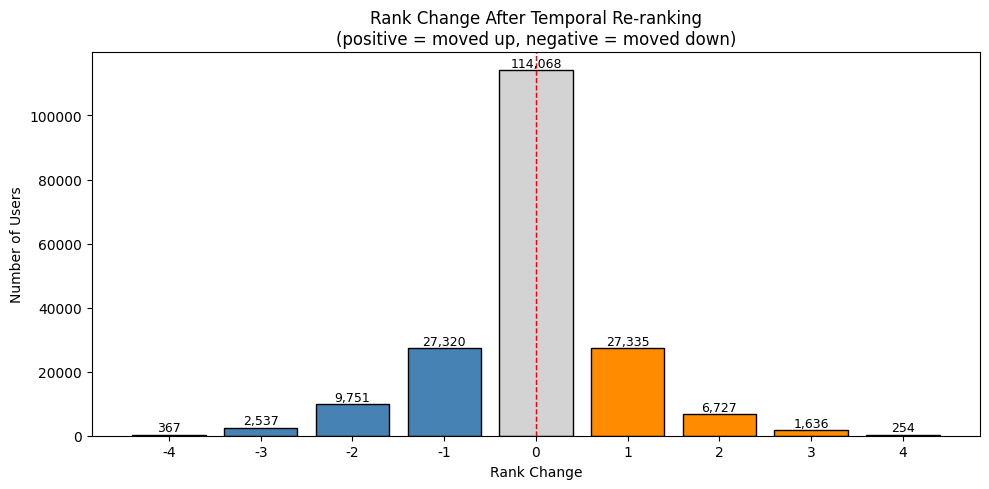

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

rank_counts = rank_comparison['rank_change'].value_counts().sort_index()
colors = ['darkorange' if x > 0 else 'steelblue' if x < 0 else 'lightgray' 
          for x in rank_counts.index]

ax.bar(rank_counts.index, rank_counts.values, color=colors, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_title('Rank Change After Temporal Re-ranking\n(positive = moved up, negative = moved down)')
ax.set_xlabel('Rank Change')
ax.set_ylabel('Number of Users')
ax.set_xticks(range(-4, 5))
ax.set_xticklabels([str(x) for x in range(-4, 5)])

# Add count labels on top of each bar
for x, y in zip(rank_counts.index, rank_counts.values):
    ax.text(x, y + 200, f'{y:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rank_change_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### 4.4 Observations
* The temporal model shows a 0.13% relative improvement over the baseline (technically better but practically negligible)
* This is consistent with the rank improvement analysis: temporal re-ranking helps and hurts roughly equal numbers of users, resulting in near-zero net gain
* The small improvement makes sense given the limitations of the evaluation setup: the leave-one-out test holds out each user's highest affinity category, which is not necessarily the category that benefits most from temporal boosting
* A more appropriate evaluation would test whether users convert on temporally boosted categories at higher rates, but that would require a live A/B test rather than offline evaluation on historical data

---

## 5. Limitations and Future Work

### 5.1 Limitations

**1. Offline evaluation underestimates temporal re-ranking value**
* The leave-one-out evaluation was designed for notebook 06's collaborative filtering model, not for re-ranking
* It holds out each user's highest affinity category, not necessarily the category that benefits most from temporal boosting
* The real value of temporal re-ranking can only be measured in a live system 
where you observe whether users actually purchase temporally boosted categories
* A proper evaluation would require an A/B test comparing baseline vs temporal 
recommendations in production

**2. Approximate category-time signal**
* Session features don't contain category information directly. I inferred which categories were purchased at which times by joining user purchase history with converted session times through `user_id`
* This is an approximation, a user who purchased electronics and had a converted session at 9am doesn't necessarily mean they bought electronics at 9am. They could have bought from a different category in that session
* The raw event log (`ecommerce_oct_nov_clean.parquet`) would give exact 
category-level purchase timestamps but was too large to load in this notebook

**3. Last session as temporal proxy**
* Each user's most recent session was used as their temporal context for re-ranking. So it assumes users tend to shop at consistent times
* This assumption doesn't always true. For example, a user who usually shops on Sunday mornings might have last visited on a Friday afternoon
* A production system would use the actual current time rather than a proxy

**4. Shrinkage factor not formally optimized**
* The shrinkage factor of 5,000 was chosen based on visual inspection of the 
natural gap in purchase counts between categories
* A grid search evaluated against NDCG@K would produce a more justifable choice

**5. November 15 data gap**
* November 15 was excluded from seasonal lift factors due to a confirmed data collection failure (only 1 conversion across 763,850 sessions)
* The root cause of this failure is unknown and could indicate broader data quality issues in the dataset

---

### 5.2 Notes for Future Work

* **A/B testing**:the most meaningful evaluation of temporal recommendations 
would be a live experiment comparing baseline vs temporal recommendations
* **Exact category purchase timestamps**: recomputing category-level temporal 
lift from the raw event log would eliminate the approximation introduced by 
joining through user_id
* **Finer temporal granularity**: combining hour x day x category into a 
single lift factor rather than multiplying three separate factors would capture 
interaction effects (e.g. Sunday mornings may be different from Sunday evenings)
* **More data**: with only two months of data, seasonal patterns are limited. 
A full year would reveal stronger seasonal signals and make the November 17 
promotional effect easier to contextualize

### AI Disclosure
* Claude was used to help give me a starting point for this notebook. I asked it to give me recommendations on what methods I could possibly use. It gave me various sources to reference.
* Claude was also used to reformat outputs to be clearer (plots and labels for print statements)
* Throughout the process of coding, I often asked it syntax questions and about pandas python methods (for example: "what are the parameters for the `.map()` method")
* All observations and notes included in this notebook are written by me and from my own thought process